# <b>ADM 3080 — Analítica con Python — Universidad San Francisco de Quito</b>
<h2><b>Proyecto de Medio Semestre</b></h2>
<i>Lunes, 23 de marzo de 2026</i>
<hr>
<ul>
    <li><b>Integrantes del Grupo</b>: Santiago Arellano [00328370]</li>
    <li><b>NRC del Curso</b>: 2041</li>
    <li><b>Profesor</b>: Juan Felipe Nájera Puente</li>
</ul>
<hr>

## Introducción al Proyecto

<hr>

## Análisis Descriptivo de los Datos

En esta sección, se realizará una exploración estática de los datos, *as-is* provenientes del dataset proporcionado para la realización del proyecto de medio semestre, con un enfoque en la exploración base de los conteos de valores nulos y la determinación del grado de *dirtiness presente en la data actual, así como la forma y tipo de datos registrados a lo largo de la base de datos, con muestras aleatorias de las entradas del dataset con el fin de observar en una muestra pequeña la afectación de valores nulos, `NaN`(s) u otras afectaciones a la calidad de los datos.

Con esto en mente, además de una exploración de los datos en general, también se analizará la necesidad de un renombramiento de columnas, encoding más fuerte para los valores internos del dataset, etc., esto con el fin de contrastar lo definido en la guía del dataset con los datos obtenidos.

### Guía base de la estructura del dataset

Los datos están distribuidos en un solo archivo *CSV*, importando desde *GitHub Raw links* para mayor comodidad a la hora de ejecutar este cuaderno de Python en otros sistemas en donde el acceso a archivos csv, la forma de manejar archivos del sistema operativo o la ubicación del archivo podrían causar problemas de ejecución innecesarios. En base de este archivo *CSV* y la guía del dataset se ha definido el siguiente listado de los campos y su respectiva descripción.

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: center; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Campo</th>
            <th style="border: 1px solid black; padding: 8px;">Tipo de Dato Esperado</th>
            <th style="border: 1px solid black; padding: 8px;">Descripción</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">userID</td>
            <td style="border: 1px solid black; padding: 8px;">Entero</td>
            <td style="border: 1px solid black; padding: 8px;">Id. de usuario</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Track</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Título de la canción</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">artist</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Nombre del cantante o grupo</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">genre</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Género musical</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">City</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Ciudad del usuario</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">time</td>
            <td style="border: 1px solid black; padding: 8px;">Hora</td>
            <td style="border: 1px solid black; padding: 8px;">La hora exacta en la que se escuchó la canción</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Day</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Día de la semana</td>
        </tr>
    </tbody>
</table>
</div>

Como lo demuestra la tabla anterior, la estructura del dataset es simple y pequeña, con solo unos pocos campos y la mayoría manejados en el contexto de variables de tipo texto, pocas variables numéricas, y con un dato que generalmente es poco util para codificar debido a que variables como *artist* o *genre* tienen demasiadas opciones que dificultarían un proceso de *one-hot encoding* u *label encoding*, por lo que para este análisis desde un principio se considera necesaria una estandarización del contenido, pero no un *encoding* profundo dado que no es un dataset que se esté preparando para *machine learning*, sino que es un dataset de prueba para un análisis de datos común.

### Librerías Requeridas
Para el presente proyecto, se ha optado por trabajar mediante un entorno *managed* de Python a través de *Python Venv(s)* permitiendo el aislamiento de las librerías requeridas para el trabajo. En este contexto, los comandos a ejecutar a continuación se encargan de la instalación de varias librerías para el trabajo, lo que requiere que Python se encuentre instalado y definido dentro del **PATH** o en su caso, en la carpeta de configuración */bin* o */sbin*.
<br><br>
Para la realización del trabajo, se ha considerado necesario la inclusión de diversas librerías. El siguiente listado detalla la razón de la inclusión de la librería en el desarrollo del proyecto:

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: justify; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Librería</th>
            <th style="border: 1px solid black; padding: 8px;">Uso</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Numpy</td>
            <td style="border: 1px solid black; padding: 8px;">Librería de análisis numérico con fuertes características para operaciones algebráicas, matriciales y con un backend implementado en C++ por lo que permitirá la realización de operaciones numéricas rápidamente.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Pandas</td>
            <td style="border: 1px solid black; padding: 8px;">Librería base para el análisis del archivo CSV, su manipulación en forma de carga, datos, y agregaciones que permitirán dar respuesta a las preguntas de investigación definidas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Matplotlib</td>
            <td style="border: 1px solid black; padding: 8px;">Base de las visualizaciones en el caso de ser necesarias para el desarrollo del proyecto o la exploración visual de los datos.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Seaborn</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib en el caso de requerir visualizaciones más avanzadas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Squarify</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib para la realización de Treemaps en Python.</td>
        </tr>
    </tbody>
</table>
</div>
<br><br>
En este contexto, las librerías seran importadas  usando un álias al nombre original para facilidad de uso

In [1]:
from squarify import layout
#? 1. Instalacion de las librerias requeridas para ejecutar el codigo de las siguientes secciones

%pip install numpy "pandas==3.0.0" matplotlib seaborn squarify "pandas-stubs"


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#? 2. Seleccion y carga de las librerias mediante aliases para su uso directo en el codigo con nombres mas simples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

### Carga del Dataset mediante GitHub Raw
Para el manejo del dataset en el programa, y evitar la necesidad del uso de formatos de directorios extensivos para asegurar la carga de datos, se optó por subir el repositorio completo a GitHub y usar el enlace del archivo csv en formato *RAW* desde la plataforma en el repositorio de libre acceso del proyecto, con esto el sistema puede leer el archivo sin problemas en cualquier dispositivo con acceso a internet.
<br><br>
Para efecto de este proyecto se consideró la creación de una muestra base de los datos bajo el nombre de `data_as_is` que contiene la data tomada desde GitHub como una base que solo será explorada en esta sección, mientras que una *deep copy* de estos datos será usada dentro de la fase de manipulación de los datos y prueba de hipótesis para tener un registro de los datos siempre limpio como *fallback*

In [3]:
#? 1. Carga del dataset mediante GitHub Raw
data_as_is = pd.read_csv("https://raw.githubusercontent.com/Volv1t3/MidtermDataAnalysisProject/refs/heads/main/src/res/data/music_project_en.csv")

### Exploración Inicial de los Datos
Para esta sección se considera que debemos analizar los datos de una manera previa conocida como EDA, sin realizar modelamientos como TSNE que involucrarían un trabajo más fuerte sobre las entradas de datos. En este contexto, es importante reconocer que requerimos primero analizar la forma, las dimensiones de los datos, las estadísticas claves y el conteo por ejemplo de nulos, la distribución contabilizada de las veces que se repite un artista, agrupaciones por ciudad, etc., todos datos de analisis base orientados a entender la forma de los datos y desarrollar un modelo base de la data

In [4]:
#? 1. Exploracion base de la forma de los datos, correspondiente a shape, describe, e info
print(f"El dataset tiene {data_as_is.shape[0]} filas")
print(f"El dataset tiene {data_as_is.shape[1]} columnas")

El dataset tiene 65079 filas
El dataset tiene 7 columnas


En este caso notamos que el dataset es bastante amplio teniendo muchas entradas para la cantidad de columnas que registra, lo que demuestra que es un dataset util para un análisis de este estilo en donde habrá datos suficientes para contrastar las hipótesis planteadas con respecto a los datos obtenidos

In [5]:
#? 2. Exploracion de describe
data_as_is.describe()

,userID,Track,artist,genre,City,time,Day
count,65079,63736,57512,63881,65079,65079,65079
unique,41748,39666,37806,268,2,20392,3
top,A8AE9169,Brand,Kartvelli,pop,Springfield,08:14:07,Friday
freq,76,136,136,8850,45360,14,23149


En este caso, `describe()` no nos retorna mayor cantidad de información, dado que los datos en este momento se estan guardando en su totalidad como objetos, specificamente de tipo string dado que los IDs de los usuarios son alfanuméricos, Track tiene valores tanto numéricos como alfanuméricos, etc. Esto nos demuestra que para el caso de la limpieza de los datos vamos a tener que realizar una revisión de los tipos de datos y revisar si tenemos que tomar medidas de limpieza con respecto a duplicados, o valores nulos.

In [6]:
#? 3. Exploracion de info
data_as_is.info()

<class 'pandas.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0     userID  65079 non-null  str  
 1   Track     63736 non-null  str  
 2   artist    57512 non-null  str  
 3   genre     63881 non-null  str  
 4     City    65079 non-null  str  
 5   time      65079 non-null  str  
 6   Day       65079 non-null  str  
dtypes: str(7)
memory usage: 3.5 MB


La visión desde `info()` confirma nuestras sospechas sobre el tipo de dato y los valores nulos, específicamente notamos que las columnas de `Track, artist, y genre` tienen un conteo de nulos no cero, lo que representa un problema para el análisis posterior dado que los valores nulos en estos campos imposibilitan el análisis de los registros dado que no existe ni género que agregar, ni artista que considerar para rellenar siquiera los campos. Por lo tanto, desde este momento considero clave considerar la eliminación de aquellos registros en donde no se conozca cualquiera de los dos campos, inclusive hasta género, dado que el total de valores nulos hace que parte de nuestros datos sean inútiles si se usaran para procesos de análisis, porque no se conoce la data más crítica para el análisis.

In [7]:
#? 4. Exploracion del conteo de nulos mediante isna
print("Conteo de valores nulos por columna:")

#? 4.1 Realizamos una suma de los valores isna() en la data, la suma se hace en base de todas las columnas, por lo que el implicito de sum es axis=0, luego cambiamos el nombre
#? a la serie y finalmente convertimos a frame para realizar filtrado con mascaras de bits facilmente
null_data = data_as_is.isna().sum(axis=0).rename("Conteo Nulos").to_frame()

#? 4.2 Filtramos en base a quienes tienen un conteo mayor a cero, dado que el resto de columnas todas son cero
null_data = null_data[null_data['Conteo Nulos'] > 0]

#? 4.3 Ordenamos en descendente para ver mejor los datos
null_data = null_data.sort_values(by=['Conteo Nulos'], ascending=False)
null_data

Conteo de valores nulos por columna:


,Conteo Nulos
artist,7567
Track,1343
genre,1198


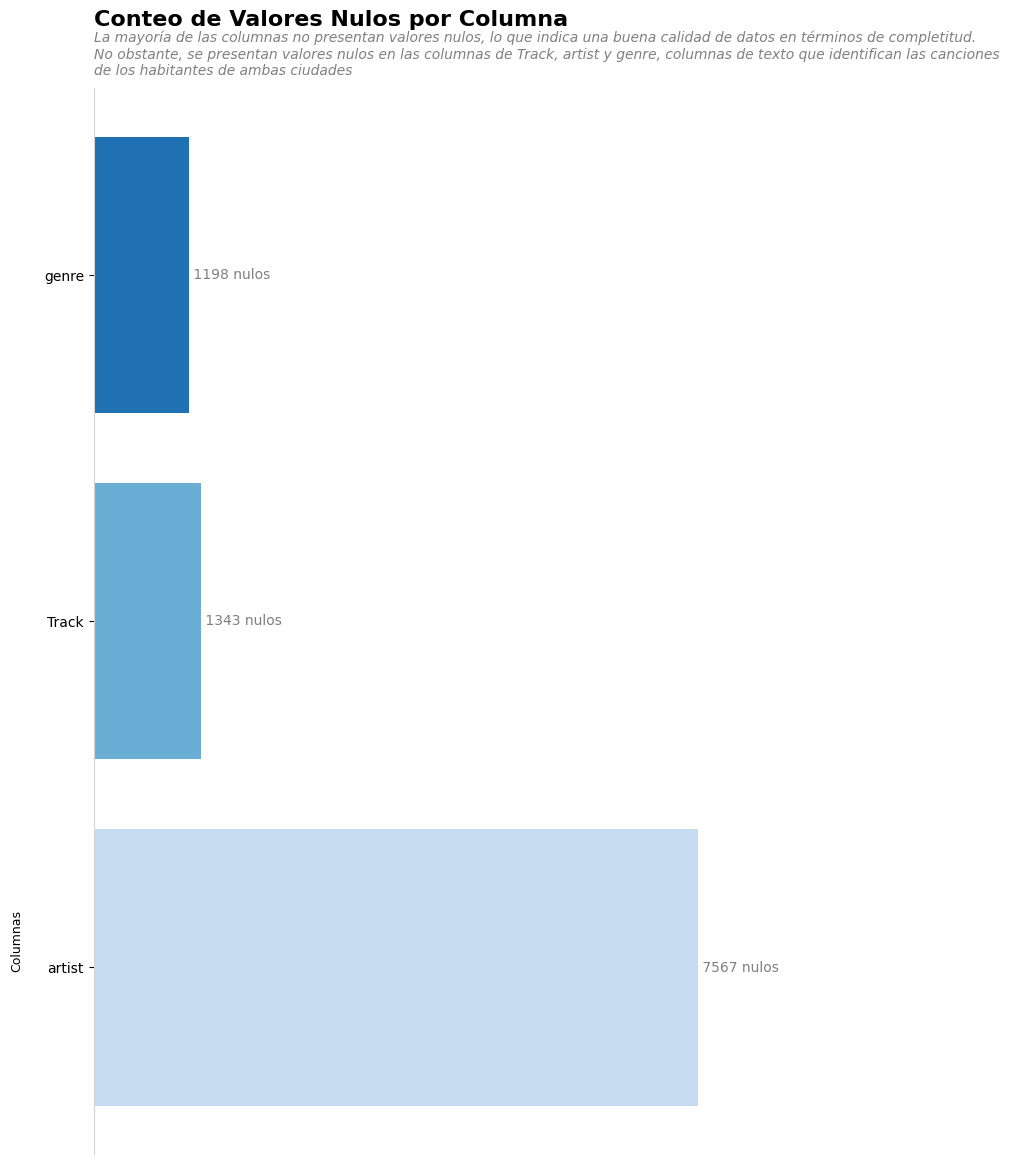

In [8]:
from seaborn.palettes import _ColorPalette
#? Generacion de una funcion para imprimir bar charts con storytelling

from typing import Any

#? 4.1 Funcion para la visualizacion de colores del patron de Blues de Seaborn con el numero de series a representar
def generate_blue_palette(n: int) -> _ColorPalette:
    """
    Funcion encargada de generar una paleta de colores replicable en base de la paleta built-in de Blues de Seaborn
    y usando el parametro n para determinar cuantos colores generar y retornar para la visualizacion
    :param n: entero representativo de la cantidad de colores necesarios
    :return: listado de colores
    """
    return sns.color_palette("Blues", n)

#? 4.2 Generamos los colores para la serie de datos de null_data que contiene el conteo de nulos mayores que cero


#? 4.3 Definimos una mini funcion para la generacion de barcharts orientados al storytelling, con parametros programables para evitar la reescritura del codigo de las visualizaciones, y con un formato estandarizado para mantener una estetica uniforme en las visualizaciones del proyecto
def crear_barchart_storytelling(
        data: pd.DataFrame,
        x_axis_data: Any | str | pd.Series,
        x_axis_title: str,
        y_axis_data: Any | str | pd.Series,
        y_axis_title: str,
        fig_size: tuple[int, int],
        color_palette: Any,
        title: str,
        subtitle: str,
        #? Orientacion
        orientation: str = 'horizontal',
        #? Grid
        grid_axis: str = 'x',
        grid_color: str = 'lightgray',
        grid_linestyle: str = '--',
        grid_alpha: float = 0.4,
        #? Spines
        visible_spines: set[str] = None,
        spine_colors: dict[str, str] = None,
        #? Bar labels
        show_bar_labels: bool = True,
        bar_label_offset: float = 10,
        bar_label_fontsize: int = 10,
        bar_label_color: str = 'gray',
        bar_label_formatter: callable = None,
        #? Hue y orden
        hue: str = None,
        hue_order: list[str] = None,
        order: list[str] = None,
        #? Ejes
        show_x_axis: bool = True,
        show_y_axis: bool = True,
        x_tick_rotation: float = 0,
        y_tick_rotation: float = 0,
        #? Leyenda
        show_legend: bool = False,
        legend_position: str = 'best',
        legend_title: str = None
) -> tuple[plt.Figure, plt.Axes]:
    """
    Funcion diseñada para generar una visualizacion orientada al storytelling con un titulo centrado, subtitulo con insight, y
    data programable para evitar la reescritura del codigo de las visualizaciones.

    Parameters:
        data (pd.DataFrame): The data for the bar chart.
        x_axis_data (Any): nombre de la columna o serie de datos correspondiente al eje x
        x_axis_title (str): titulo del eje x
        y_axis_data (Any): nombre de la columna o serie de datos correspondiente al eje y
        y_axis_title (str): titulo del eje y
        fig_size (tuple): tamano de la figura
        color_palette (Any): Paleta de colores para las barras
        title (str): Titulo del grafico
        subtitle (str): Subtitulo con el insight
        orientation (str): 'horizontal' o 'vertical' (default: 'horizontal')
        grid_axis (str): 'x', 'y', 'both', o 'none' (default: 'x')
        grid_color (str): color de la grid (default: 'lightgray')
        grid_linestyle (str): estilo de linea de la grid (default: '--')
        grid_alpha (float): transparencia de la grid (default: 0.4)
        visible_spines (set): set de spines visibles e.g. {'bottom', 'left'} (default: {'bottom'})
        spine_colors (dict): colores por spine e.g. {'bottom': 'lightgray'} (default: {'bottom': 'lightgray'})
        show_bar_labels (bool): mostrar etiquetas sobre las barras (default: True)
        bar_label_offset (float): distancia de la etiqueta respecto a la barra (default: 5)
        bar_label_fontsize (int): tamano de fuente de las etiquetas (default: 10)
        bar_label_color (str): color de las etiquetas (default: 'gray')
        bar_label_formatter (callable): funcion para formatear el valor e.g. lambda v: f'{v:.2f}%' (default: str)
        hue (str): columna para agrupar barras por color (default: None)
        hue_order (list): orden explicito de las categorias del hue (default: None)
        order (list): orden explicito de las categorias del eje categorico (default: None)
        show_x_axis (bool): mostrar eje x (default: True)
        show_y_axis (bool): mostrar eje y (default: True)
        x_tick_rotation (float): rotacion de las etiquetas del eje x (default: 0)
        y_tick_rotation (float): rotacion de las etiquetas del eje y (default: 0)
        show_legend (bool): mostrar leyenda (default: False)
        legend_position (str): posicion de la leyenda (default: 'best')
        legend_title (str): titulo de la leyenda (default: None)

    Returns:
        tuple[plt.Figure, plt.Axes]: figura y ejes del grafico generado
    """

    #? 0. Defaults para parametros mutables
    #? Aqui cargamos las variables de las splines, o las lineas de la cuadricula que se mostraran dependiendo de los ejes que se solicitan en la funcion
    if visible_spines is None:
        if show_y_axis and show_x_axis:
            visible_spines = {'left', 'bottom'}
        elif show_x_axis:
            visible_spines = {'bottom'}
        else:
            visible_spines = {'left'}
    #? Aqui le anadimos los colores de las spines dependiendo de lo que queramos resaltar en base de los ejes que se muestran
    if spine_colors is None:
        if show_y_axis and show_x_axis:
            spine_colors = {'bottom': 'lightgray', 'left':'lightgray'}
        elif show_x_axis:
            spine_colors = {'bottom': 'lightgray'}
        else:
            spine_colors = {'left': 'lightgray'}
    #? Si no tenemos un label formatter, nuestra funcion lambda para el formato corresponde al mismo valor
    if bar_label_formatter is None:
        bar_label_formatter = lambda v: f'{v}'


    #? 1. Definimos el tipo de grafico como barplot en su propio subplot 1x1
    fig, ax = plt.subplots(figsize=fig_size)

        #? 1.1 Dibujamos las barras con matplotlib directamente y ordenamos la data si es que el eje es categorico
    plot_data = data.copy()
    plot_colors = color_palette

    #? 1.1.a Determinamos cual eje es categorico segun la orientacion
    #? Si es un bar chart entonces esperamos que las categorias esten en la y y los datos en la x
    if orientation == 'horizontal':
        cat_axis = y_axis_data
        val_axis = x_axis_data
    #? Si es un colum chart ersperamos alreves
    else:
        cat_axis = x_axis_data
        val_axis = y_axis_data

    #? Guardamos las categortias y los valores en sus variables respectivas para usar
    #? en los graficos
    categories = plot_data[cat_axis] if isinstance(cat_axis, str) else cat_axis
    values = plot_data[val_axis] if isinstance(val_axis, str) else val_axis


    #? Creamos el grafico especifico dependiendo de la orientacion
    if orientation == 'horizontal':
        bars = ax.barh(categories, values, color=colors)
    else:
        bars = ax.bar(categories, values, color=colors)



    #? 2. Le anadimos las labels requeridas al grafico
    ax.set_title(title, fontsize=16, fontweight='bold', loc='left', color='black', pad=45)
    ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
            fontsize=10, fontstyle='italic', color='gray', va='bottom', ha='left')
    #? 2.1 Le anadimos las labels a los ejes
    if x_axis_title is not None and isinstance(x_axis_title, str):
        ax.set_xlabel(x_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='left', x=0)
    if y_axis_title is not None and isinstance(y_axis_title, str):
        ax.set_ylabel(y_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='center', va='bottom', y=0.2)

    #? 3. Configuracion de la grid
    if grid_axis == 'none':
        ax.grid(False)
    elif grid_axis == 'both':
        ax.grid(True, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)
    else:
        ax.grid(False)
        ax.grid(True, axis=grid_axis, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)

    #? 4. Configuracion de spines
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(spine in visible_spines)
        if spine in spine_colors:
            ax.spines[spine].set_color(spine_colors[spine])

    #? 5. Visibilidad de ejes
    ax.xaxis.set_visible(show_x_axis)
    ax.yaxis.set_visible(show_y_axis)

    #? 5.1 Rotacion de ticks
    if x_tick_rotation != 0:
        ax.tick_params(axis='x', rotation=x_tick_rotation)
    if y_tick_rotation != 0:
        ax.tick_params(axis='y', rotation=y_tick_rotation)

    #? 6. Etiquetas sobre las barras
    if show_bar_labels:
        if orientation == 'horizontal':
            ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
        else:
            ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

        for bar in bars:
            if orientation == 'horizontal':
                width = bar.get_width()
                if width != 0:
                    ax.text(width, bar.get_y() + bar.get_height() / 2,
                            bar_label_formatter(width), color=bar_label_color,
                            va='center', fontsize=bar_label_fontsize)
            else:
                height = bar.get_height()
                if height != 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, height,
                            bar_label_formatter(height), color=bar_label_color,
                            ha='center', fontsize=bar_label_fontsize, va='bottom')



    #? 7. Leyenda
    if show_legend and hue is not None:
        ax.legend(title=legend_title, loc=legend_position)
    elif not show_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    plt.tight_layout(pad=2.0)
    plt.show()

null_data_reset = null_data.reset_index().rename(columns={'index': 'Columna'})
colors = generate_blue_palette(len(null_data_reset))

crear_barchart_storytelling(
    data=null_data_reset,
    y_axis_data='Columna',
    x_axis_title='Conteo Nulos',
    x_axis_data='Conteo Nulos',
    y_axis_title='Columnas',
    show_y_axis=True,
    show_x_axis=False,
    bar_label_formatter= lambda v: f' {v} nulos ',
    fig_size=(10, 12),
    color_palette= colors,
    orientation='horizontal',
    order=['genre','track','artist'],
    title='Conteo de Valores Nulos por Columna',
    subtitle='La mayoría de las columnas no presentan valores nulos, lo que indica una buena calidad de datos en términos de completitud.\n'
             'No obstante, se presentan valores nulos en las columnas de Track, artist y genre, columnas de texto que identifican las canciones\n'
             'de los habitantes de ambas ciudades'
)


A la visualización anterior, desarrollada como base para la demostración de los valores nulos del dataset, nos permite evidenciar un problema serio, la columna importante de Track, seguida de las columnas que determinan este dato, artists y genre tienen un número elevado de valores nulos, lo que representa un problema para el análisis posterior dado que los valores nulos en estos campos imposibilitan el análisis de los registros dado que no existe ni género que agregar, ni artista que considerar para rellenar siquiera los campos. Para explorar este caso más a fondo, considero la creación de un conteo de valores que determine aquellos valores nulos en donde los tres campos estén vacíos, donde los dos campos estén vacíos, y donde aunque sea un campo este vacío


In [9]:
#? 5. Exploracion adicional sobre los valores nulos
data_as_is_copy = data_as_is.copy(deep=True)

data_as_is_copy['Clasificacion_Nulos'] = data_as_is.iloc[:,1:4].isna().apply(lambda x: '3 Nulos' if x.sum() == 3 else ('2 Nulos' if x.sum() == 2 else ('1 Nulo' if x.sum() == 1 else '0 Nulos')), axis=1)


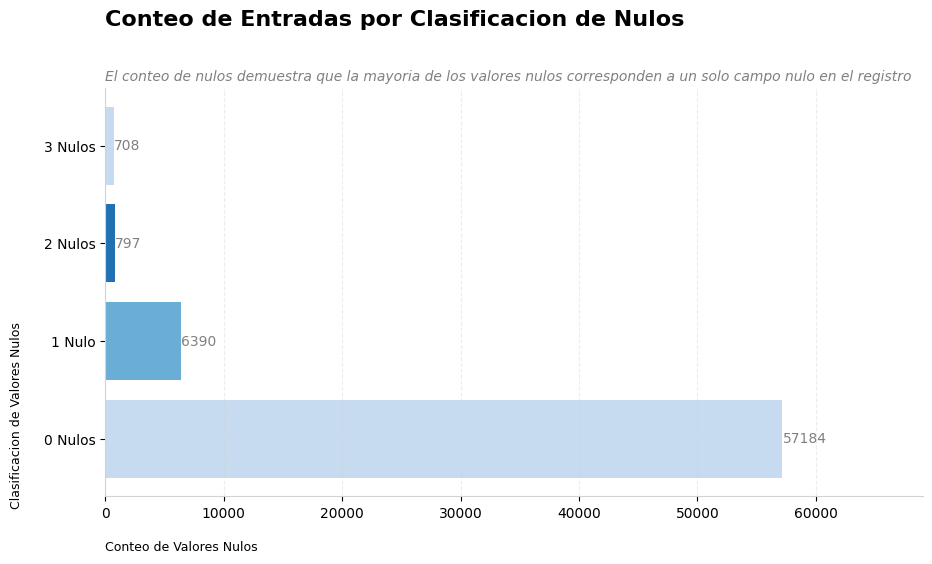

In [10]:
datos_nulos_conteo_general = pd.DataFrame(data_as_is_copy['Clasificacion_Nulos'].value_counts())
crear_barchart_storytelling(
    data=datos_nulos_conteo_general.reset_index(),
    x_axis_data='count',
    y_axis_title='Clasificacion de Valores Nulos',
    show_bar_labels=True,
    y_axis_data='Clasificacion_Nulos',
    x_axis_title='Conteo de Valores Nulos',
    fig_size=(10,6),
    order=['3 Nulos', '1 Nulo', '2 Nulos', '0 Nulos'].reverse(),
    color_palette=generate_blue_palette(len(['0 Nulos', '1 Nulo', '2 Nulos', '3 Nulos'])),
    title="Conteo de Entradas por Clasificacion de Nulos",
    subtitle="El conteo de nulos demuestra que la mayoria de los valores nulos corresponden a un solo campo nulo en el registro")

In [11]:
datos_nulos_conteo_general.reset_index()

,Clasificacion_Nulos,count
0,0 Nulos,57184
1,1 Nulo,6390
2,2 Nulos,797
3,3 Nulos,708


El analisis anterior nos muestra un problema grave que tiene nuestro dataset, en general tenemos tres tipos de entradas con problemas, aquellas con uno, dos o tres valorers nulos. Aquellas con tres valores nulos son menores, representando solo 708 entradas del dataset, pero se considera que eixsten 6390 entradas con aunquesea un valor nulo. Conocimiento que los datos de nulos se agrupan generalmente en la columna de artistas, es posible identificiar que el nulo en este caso es nulo de artista, y que tenemos 6390 entradas que posiblemente tengan un nulo en artista, lo que nos dificulta la agrupacion por este tipo de dato. Para corroborar esta idea, es prudente analizar con mas detenimiento los valores nulos y sus combinaciones, en este caso al tener tres valores tenemos ocho combinaciones posibles, si analizamos la posibilidad de las ocho, y podremos comprender de mayor manera el problema

In [12]:
#? 5. Exploracion adicional sobre los valores nulos

#? 5.1 Extraemos las columnas del analisis, las columnas de track, artist and genre para usar loc en base de nombres mediante [] en lugar de iloc con indices para extraer los datos para el analisis
cols = data_as_is.columns[1:4]

#? 5.2 Aplicamos una bitmask orientada a marcar aquellos valores notna() o no nulos con un 1 y los valores nulos con 0, como una mascara
#? binaria para las tres columnas
null_bits = data_as_is[cols].notna().astype(int)

#? 5.3 Aplicamos un lambda directo hacia la mascara binaria aplicada a las tres columnas para reducir por fila cada uno de los grupos de columnas, y usando estos valores establecer los conteos de valores nulos y las clases.
data_as_is_copy['Clasificacion_Nulos_Binario'] = (
    #? 5.3.1 Internamente aplicamos una funcion apply a las columnas extraidas de data_as_is en donde usamos la data extraida para crear
    #? la nueva clasificacion
    null_bits.apply(
        #? 5.3.2 El string requiere la concatenacion del grupo de columnas en uno solo para generar el bitmap de valor presente o o.
        #? Luego toma la suma de los valores y los formatea con la longitud de las columnas de analisis para determinar cuantos valores hay o no por grupo. Finalmente determina el nombre de la columna que es nula y los une para generar el listado de columnas nulas
        #? lo que nos permite evaluar la distribucion de nulos por grupo de columnas nulas
        lambda r: f"{''.join(map(str, r))} ({r.sum()}/{len(cols)} presentes) - Nulos: {', '.join(cols[r == 0]) or 'Ninguno'}",
        axis=1
))


In [13]:
clasificacion_binaria_extraida = pd.DataFrame(data_as_is_copy['Clasificacion_Nulos_Binario'].value_counts())
clasificacion_binaria_extraida

,count
Clasificacion_Nulos_Binario,
111 (3/3 presentes) - Nulos: Ninguno,57184
101 (2/3 presentes) - Nulos: artist,6062
"000 (0/3 presentes) - Nulos: Track, artist, genre",708
"001 (1/3 presentes) - Nulos: Track, artist",635
110 (2/3 presentes) - Nulos: genre,328
"100 (1/3 presentes) - Nulos: artist, genre",162


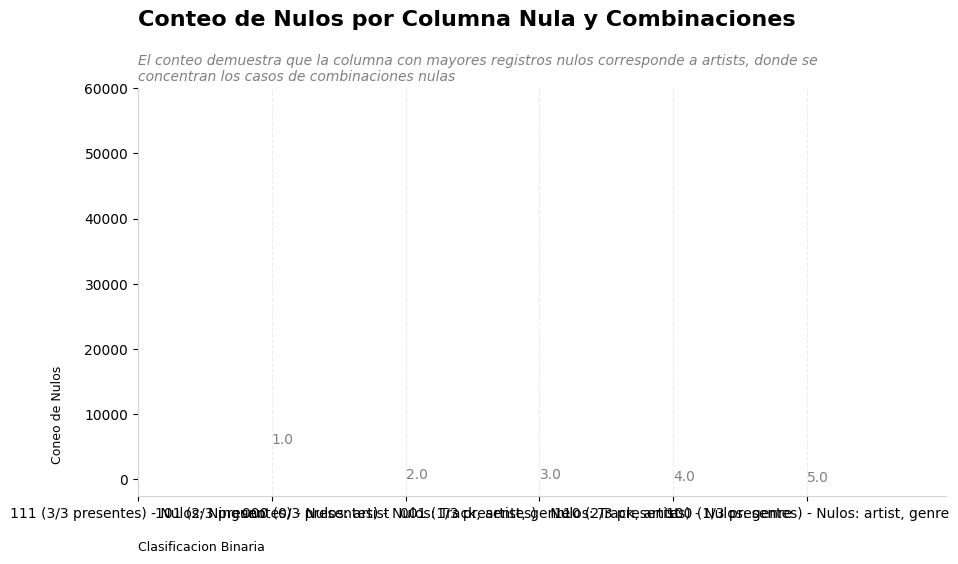

In [14]:
crear_barchart_storytelling(
    data=clasificacion_binaria_extraida.reset_index(),
    x_axis_data="Clasificacion_Nulos_Binario",
    x_axis_title='Clasificacion Binaria',
    y_axis_data="count",
    y_axis_title='Coneo de Nulos',
    fig_size=(10,6),
    color_palette=generate_blue_palette(len(clasificacion_binaria_extraida.index)),
    title="Conteo de Nulos por Columna Nula y Combinaciones",
    subtitle="El conteo demuestra que la columna con mayores registros nulos corresponde a artists, donde se\nconcentran los casos de combinaciones nulas")

En este caso notamos que los datos faltantes corresponden en su mayoría a artists, una columna de texto en donde se registra el cantautor de las canciones registradas para cada una de las ciudades. Viendo la cantidad de valores nulos registrados en esa columna, es importante notar que las combinaciones adicionales, donde se puede encontrar valores nulos en genre, o en track, son significativamente menores, la mayoría de los registros totalizados a menos de 1000 registros con dos o más valores faltantes, lo que nos demuestra que el problema de nulos, concentrado en artists, si tiene una solución. En el caso de la columna de artists, podemos marcar los valores nulos como "Undefined" o "Unknown" lo que nos elimina los casos de valores nulos y nos permite retener un total de 6000 muestras. En el caso de aquellas en donde existe más de un campo faltante, es claro que no podremos reconstruir la información del artista o el género si solo tenemos el nombre de la canción, porque este tipo de proceso cae fuera del alcance del proyecto, en el caso de artists y track, también estamos en un caso donde no se puede recuperar la información necesaria y se debería de eliminar ese registro.
<br><br>
Con esto en mente, consideramos necesario la eliminación de los registros *100* o que tienen nulo artists y genre, pero no Track, los registros *001* que tienen solo genre y nada de artista ni nombre del Track, y los registros *000* que no tienen ningún campo registrado. Estas eliminaciones terminarían reduciendo la cantidad de valores del dataset por 1505 registros.
<br><br>
Una vez analizado el contexto de los valores nulos, considero importante revisar un poco más a detalle las otras columnas registradas en el dataset, con exploraciones mediante pandas para analizar puntos claves de los datos.

In [15]:
#* 6. Conteo de records de datos por ciudad
conteo_ciudad = pd.DataFrame(data_as_is['  City  '].value_counts())
conteo_ciudad

,count
City,
Springfield,45360
Shelbyville,19719


Es interesante notar aquí que el dataset esta *demasiado* desbalanceado. No solo hay casi el doble de registros para Springfield que para Shelbyville, sino que además, la cantidad de registros para Springfield es tan alta que podría afectar el análisis posterior. Por otro lado, esto afecta nuestra visualización de datos correspondientes a los nulos, dado que podemos tener mayor cantidad de nulos o valores faltantes en el caso de Shelbyville, y no en Springfield.

In [16]:
#* 6.1 Conteo de records nulos, bajo la misma categorizacion pero bajo una agrupacion por ciudad

conteo_ciudad_valores_nulos = data_as_is_copy.groupby(by="  City  ")["Clasificacion_Nulos_Binario"].value_counts(sort=True, normalize=True).apply(lambda val: f"{round(val*100,2)} %")
conteo_ciudad_valores_nulos

  City       Clasificacion_Nulos_Binario                      
Shelbyville  111 (3/3 presentes) - Nulos: Ninguno                 88.25 %
             101 (2/3 presentes) - Nulos: artist                   8.98 %
             001 (1/3 presentes) - Nulos: Track, artist            1.28 %
             000 (0/3 presentes) - Nulos: Track, artist, genre     0.84 %
             110 (2/3 presentes) - Nulos: genre                     0.4 %
             100 (1/3 presentes) - Nulos: artist, genre            0.26 %
Springfield  111 (3/3 presentes) - Nulos: Ninguno                  87.7 %
             101 (2/3 presentes) - Nulos: artist                   9.46 %
             000 (0/3 presentes) - Nulos: Track, artist, genre      1.2 %
             001 (1/3 presentes) - Nulos: Track, artist            0.84 %
             110 (2/3 presentes) - Nulos: genre                    0.55 %
             100 (1/3 presentes) - Nulos: artist, genre            0.24 %
Name: proportion, dtype: str

El resultado anterior nos muestra los datos porcentuales de la proporción de todos los datos registrados para cada categoria en general, es decir, para Shelbyville y para Springfield, comparado con los valores contabilizados para cada categoría, lo que nos permite ver el efecto acumulativo porcentual de cada una de las clases de valores nulos. En este caso, la disparidad total de registros por ciudad no parecer ser un problema grave, dado que la cantidad de valores nulos de la serie 101, es decir que falte artists,es superior en el caso de Springfield que en Shellbyville.

In [17]:
#* 6.2 Conteo de records por dia
data_as_is_copy.groupby(by="  City  ")["Day"].value_counts().convert_dtypes()

  City       Day      
Shelbyville  Wednesday     7478
             Friday        6259
             Monday        5982
Springfield  Friday       16890
             Monday       16715
             Wednesday    11755
Name: count, dtype: Int64

En este caso, la exploración de la agrupación por días nos permite evidenciar que tenemos registros solo de los días Lunes, Miercoles y Viernes, lo que limita el análisis si se quisiera por ejemplo realizar un análisis de serie de tiempo real con toda la semana. No obstante, podemos realizar un análisis en base a los días y a las horas registradas.

In [18]:
#* 6.3 Conteo de generos en general
pd.DataFrame(data_as_is_copy['genre'].value_counts(dropna=False)).sort_values(by='genre')

,count
genre,
acid,1
acoustic,6
action,4
adult,27
africa,17
...,...
western,106
world,2069
worldbeat,2


In [19]:
#* 6.3.1 Conteo de generos por ciudad top 15
(data_as_is_copy.groupby("  City  ")["genre"]
 #* 6.3.1.a Conteo de valores de cada genero por ciudad, incluyendo nulos
 .value_counts(dropna=False)
 #* 6.3.1.b Reagrupamos por ciudad (nivel 0 del multi-index) para operar por grupo
 .groupby(level=0)
 #* 6.3.1.c Tomamos los 15 generos mas frecuentes de cada ciudad
 .nlargest(15)
 #* 6.3.1.d Eliminamos el nivel redundante de ciudad creado por nlargest
 .droplevel(0)
 #* 6.3.1.e Convertimos a DataFrame con nombre de columna descriptivo
 .to_frame(name="count"))


count
  City      genre             
Shelbyville pop           2597
            dance         2054
            rock          2004
            electronic    1842
            hip            992
            alternative    700
            classical      684
            rusrap         604
            ruspop         565
            world          553
            jazz           522
            metal          400
            soundtrack     352
            rnb            345
            rap            331
Springfield pop           6253
            dance         4707
            rock          4188
            electronic    4010
            hip           2156
            classical     1712
            world         1516
            alternative   1466
            ruspop        1453
            rusrap        1239
            jazz          1057
            NaN            904
            metal          874
            soundtrack     837
            folk           736

En este caso, la agrupación por ciudad nos demuestra que ambas ciudades comparten una base de géneros que escuchan en común, como son *pop*, *rap*, *rock*, *elecronic*, etc. que corresponden a los géneros con mas escuchas en ambas ciudades bajo los datos registrados en el dataset.

In [20]:
#* 6.3.2 Conteo de generos por ciudad y dia top 15
(data_as_is_copy.groupby(["  City  ", "Day"])["genre"]
 #* 6.3.2.a Conteo de valores de cada genero por ciudad y dia, incluyendo nulos
 .value_counts(dropna=False)
 #* 6.3.2.b Reagrupamos por ciudad y dia (niveles 0 y 1 del multi-index)
 .groupby(level=[0, 1])
 #* 6.3.2.c Tomamos los 15 generos mas frecuentes de cada combinacion ciudad-dia
 .nlargest(15)
 #* 6.3.2.d Eliminamos los niveles redundantes creados por nlargest
 .droplevel([0, 1])
 #* 6.3.2.e Convertimos a DataFrame con nombre de columna descriptivo
 .to_frame(name="count"))


count
  City      Day       genre            
Shelbyville Friday    pop           802
                      dance         683
                      rock          629
                      electronic    588
                      hip           336
...                                 ...
Springfield Wednesday jazz          297
                      soundtrack    229
                      metal         216
                      NaN           208
                      folk          190

[90 rows x 1 columns]

In [21]:
#* 6.4 Analysis de serie de tiempo basado en una transformacion sobre la hora registrada, Time, para segmentar por manana, tarde y noche
#? 6.4.1 Transformacion de la columna de time a formato datetime para facilitar la manipulacion
data_as_is_copy['time'] = pd.to_datetime(data_as_is_copy['time'], errors='coerce')
data_as_is_copy['time_range'] = data_as_is_copy['time'].apply(lambda time: 'Night' if 0 < time.hour < 6 else'Morning' if 6 <= time.hour < 12 else 'Afternoon' if  12 <= time.hour < 18 else 'Evening' if pd.notna(time) else 'Unknown')


/var/folders/3c/vp72r8cx1kx1z2gvmfkybjqc0000gn/T/ipykernel_6012/3943544338.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_as_is_copy['time'] = pd.to_datetime(data_as_is_copy['time'], errors='coerce')


In [22]:
#? 6.4.2 Aplicamos una agrupacion por la hora para analizar reproducciones totales, i.e. registros totales por ciudad y segmento del dia
data_as_is_copy.groupby(by=["  City  ", "time_range"])["time_range"].count()

  City       time_range
Shelbyville  Afternoon      7058
             Evening        6908
             Morning        5753
Springfield  Afternoon     15489
             Evening       15226
             Morning       14645
Name: time_range, dtype: int64

In [23]:
#? 6.4.3 Aplicamos una agrupacion por ciudad, dia y time_range con conteo por genero
result = data_as_is_copy.groupby(by=["  City  ", "Day", "time_range"])["genre"].value_counts(dropna=False).groupby(level=[0,1,2]).nlargest(10).droplevel([0,1,2]).to_frame(name="count")
result

count
  City      Day       time_range genre             
Shelbyville Friday    Afternoon  pop            298
                                 dance          261
                                 rock           232
                                 electronic     180
                                 hip            126
...                                             ...
Springfield Wednesday Morning    classical      126
                                 ruspop         123
                                 alternative    110
                                 world           90
                                 rusrap          86

[180 rows x 1 columns]

In [24]:
#? 6.4.3.1 Extraccion de los datos de Shellbyville para lunes por la manana y viernes en la tarde
display(result.loc["Shelbyville", "Monday", "Morning"])
result.loc["Shelbyville", "Friday", "Afternoon"]

,count
genre,
pop,238
dance,192
rock,173
electronic,154
hip,87
ruspop,68
alternative,65
rusrap,56
jazz,47


,count
genre,
pop,298
dance,261
rock,232
electronic,180
hip,126
classical,109
alternative,86
ruspop,79
rusrap,64


En este caso, el análisis preliminar muestra que en el caso de Shellbyville, los habitantes comparten un cierto número de géneros escuchados tanto el viernes por la tarde como el lunes por la mañana. Por ejemplo, pop y Dance son canciones que se registran en los dos segmentos de análisis, lo que demuestra una similitud en los géneros que escuchan los habitantes de Shelbyville en estos días. Por otro lado, los siguientes son los géneros que son únicos a ambos datasets

In [25]:
all_genres_monday_morning = result.loc["Shelbyville", "Monday","Morning"].index.tolist()
all_genres_friday_afternoon = result.loc["Shelbyville", "Friday","Afternoon"].index.tolist()

unique_genres_monday_morning = set(all_genres_monday_morning) - set(all_genres_friday_afternoon)
unique_genres_friday_afternoon = set(all_genres_friday_afternoon) - set(all_genres_monday_morning)

print(f"Generos unicos el Lunes por la Manana {unique_genres_monday_morning}")
print(f"Generos unicos el Viernes por la Tarde {unique_genres_friday_afternoon}")

Generos unicos el Lunes por la Manana {'jazz'}
Generos unicos el Viernes por la Tarde {'world'}


Este análisis preliminar nos indica que en general, en ambos horarios no existe una gran diferencia en los géneros escuchados , solo una categoría por día varía de la base de géneros musicales escuchados en Shellbyville en los horarios analizados

In [26]:
#* 6.5 Exploracion por artista musical por dia y por bloque del dia
data_as_is_copy.groupby(by=["  City  ", "Day", "time_range"])["artist"].value_counts(dropna=False).groupby(level=[0,1,2]).nlargest(15).droplevel([0,1,2]).to_frame(name="count").astype(dtype=np.int32)

count
  City      Day       time_range artist                
Shelbyville Friday    Afternoon  NaN                238
                                 Kartvelli           11
                                 Alexandra            4
                                 Sardor Rahimxon      4
                                 Drug Flash           4
...                                                 ...
Springfield Wednesday Morning    KoperniK             4
                                 Rocket               4
                                 MALFA                4
                                 Nastika              4
                                 Sabine Kors          4

[270 rows x 1 columns]

### Exploracion de Head y Tail para el Dataset Original

Aunque se ha realizado un análisis más profundo sobre los datos y su calidad, por el momento procedemos a analizar la visión general de los datos tomando un `head(10)` y un `tail(10)` para explorar la forma en la que los datos estan registrados en el dataset.

In [27]:
#? 1. Head del dataset
data_as_is.head(10)

,userID,Track,artist,genre,City,time,Day
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,20:28:33,Wednesday
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,14:07:09,Friday
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,20:58:07,Wednesday
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,08:37:09,Monday
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,08:34:34,Monday
5,842029A1,Chains,Obladaet,rusrap,Shelbyville,13:09:41,Friday
6,4CB90AA5,True,Roman Messer,dance,Springfield,13:00:07,Wednesday
7,F03E1C1F,Feeling This Way,Polina Griffith,dance,Springfield,20:47:49,Wednesday
8,8FA1D3BE,L’estate,Julia Dalia,ruspop,Springfield,09:17:40,Friday
9,E772D5C0,Pessimist,NaN,dance,Shelbyville,21:20:49,Wednesday


In [28]:
data_as_is.head(10).info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0     userID  10 non-null     str  
 1   Track     10 non-null     str  
 2   artist    9 non-null      str  
 3   genre     10 non-null     str  
 4     City    10 non-null     str  
 5   time      10 non-null     str  
 6   Day       10 non-null     str  
dtypes: str(7)
memory usage: 692.0 bytes


In [29]:
#? 2. Tail del dataset
data_as_is.tail(10)

,userID,Track,artist,genre,City,time,Day
65069,BE1AAD74,Waterwalk,Eduardo Gonzales,electronic,Springfield,20:38:59,Monday
65070,49F35D53,Ass Up,Rameez,dance,Springfield,14:08:58,Friday
65071,92378E24,Swing it Like You Mean it,OJOJOJ,techno,Springfield,21:12:56,Friday
65072,C532021D,We Can Not Be Silenced,Pänzer,extrememetal,Springfield,08:38:24,Friday
65073,83A474E7,I Worship Only What You Bleed,The Black Dahlia Murder,extrememetal,Springfield,21:07:12,Monday
65074,729CBB09,My Name,McLean,rnb,Springfield,13:32:28,Wednesday
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Shelbyville,10:00:00,Monday
65076,C5E3A0D5,Jalopiina,NaN,industrial,Springfield,20:09:26,Friday
65077,321D0506,Freight Train,Chas McDevitt,rock,Springfield,21:43:59,Friday
65078,3A64EF84,Tell Me Sweet Little Lies,Monica Lopez,country,Springfield,21:59:46,Friday


In [30]:
data_as_is.tail(10).info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 65069 to 65078
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0     userID  10 non-null     str  
 1   Track     10 non-null     str  
 2   artist    9 non-null      str  
 3   genre     10 non-null     str  
 4     City    10 non-null     str  
 5   time      10 non-null     str  
 6   Day       10 non-null     str  
dtypes: str(7)
memory usage: 692.0 bytes


Esta snapshot de los datos nos muestra que el dataset contiene un índice numérico, que es bueno dado que el `userID` no es un campo de texto, sino un campo alfanumérico, lo que dificulta su uso como un índice. Internamente, notamos que tenemos una columna Track, que no está normalizada de ninguna manera y además de tener valores nulos, la estructura en la que se encuentran registrados dificultan un análisis que no sea básico de agrupación de valores y no ML, u otros sistemas. Artists tiene el mismo problema y en este caso tiene hasta caracteres especiales que tendríamos que normalizar para trabajar con esto de una manera apropiada, finalmente genre tambien tiene problemas por caracteres especiales.

### Conclusiones del análisis hasta el momento

Como se ha definido anteriormente, el dataset se encuentra en un estado sucio, con columnas con nombres con formato incorrecto, espacios fuera de lugar y valores nulos que ascienden a los *7895* casos. Esto nos demuestra que para un set de datos con *65079* entradas el 12% de las entradas de datos representan un error de digitación distribuido en diferentes casos en donde puede faltar, una, dos o tres valores de las columnas de *track, artists y genre*. En el contexto de las columnas y los datos registrados, se ha evidenciado que la columna de *time* se encuentra registrada como un objeto, como una cadena de string cuando en realidad la necesitamos como una fecha para poder trabajar correctamente con los mecanismos internos de Pandas en el trabajo de fechas y horas.

Durante la exploración inicial realizada dentro de esta sección, al convertir la columna al tipo de fecha requerido, fue posible analizar la hora específicamente sin necesidad de realizar un parsing sofisticado e la hora, ignorando la fecha dado que son valores que originalmente vinieron en una serie sin un tiempo completo, sollo con la hora. Para el resto de las columnas no se han encontrado problemas en la forma en la que se encuentran digitados, dado que para el userID (texto alfanumérico), Track, artist, genre, CIty y Day (texto alfabético completamente) se ha identificado que el contenido de estas no rompe con la normativa esperada dentro de una columna de texto además de usar caracterés extendidos UTF en lugar de caracteres base ASCII que se esperaría en un dataset, pero esto es normal porque la música registrada no contempla un solo idioma, sino que tiene registros que contienen caracteres del alfabeto Chino, Cirílico, Japonés, Koreano, etc. En este caso, al ser un dataset de prueba disminuido y no requerir la aplicación de modelos de *machine learning*, es posible considerar como una consideración adicional que no requiere de un arreglo directo en el dataset actual. En el caso de las columnas de artist y genre también tenemos o mismo, el uso de nombres no estandarizados y caracteres no ASCII imprimibles lo que nos demuestra un dataset abierto, en donde se recolectó información de las canciones sin consideración del *locale* de los usuarios o de una normalización.

Para las columnas de City, time y Day, los valores faltantes son cero y los registros siguen un formato estandar, lo que muestra que en este caso, estas son las columnas pivote para el análisis, mientras que las otras deben ser arregladas hasta cierto punto antes de ser usadas normalmente.

Como se mencionó anteriormente, el proceso de corrección de los datos se enfocará en la eliminación de aquellas *708* entradas en donde los tres campos, track, artist y genre, se encuentran vacios (i.e. nulos), en este caso no es posible recuperar los valores de estos registros con el dataset original, y dado que no presentan un género, no son útiles para el análisis de datos requeridos para las hipótesis planteadas. Además de esto, se considera necesario la eliminación de los registros que contienen el valor de *genre* vacío, dado que no es posible usar registros sin género dado que la agregación de datos sería errónea y generaría una categoría adicional innecesaria en el dataset. En el caso de aquellos que contienen solo género, es posible rellenar estos casos con el valor de *"Unknown"* en los dos campos faltantes, artist y track, lo mismo que se puede replicar para aquellos registros que tienen track y genre,pero no tienen el nombre del artista, dado que las hipótesis planteadas, y en general el dataset se presta a un análisis a fondo de los géneros, días y horas de escucha más que de que artista o canción se trató.

<hr>

## Preprocesamiento de Datos

En esta sección, se trabajará sobre una copia del dataset original sin las columnas construidas en la primera subsección de análisis exploratorio de los datos, para corregir diversos errores del dataset y aplicar transformaciones en una base de datos limpia con la que se trabaje en blanco, aplicando las sugerencias de limpieza definidas en la sección anterior, para usar esta base de datos en la sección de análisis de datos y pruebas de hipótesis, que requerirán de un análisis más profundo de los datos, y por lo tanto, de una base de datos limpia y preprocesada para el análisis.


In [31]:
#? 1. Creacion de una copia del dataset original para trabajar sobre ella sin modificar el dataset original
data_cleaned = data_as_is.copy(deep=True)

### Limpieza I — Organización de la nomenclatura de columnas

En esta subsección vamos a aplicar una limpieza a los nombres de las columnas, transformando las columnas registradas con nombres no estándares y con espacios sin limpieza en nombres estandarizados en minúsculas y con los espacios alrededor limpiados.

In [32]:
#? 1. Correcion por columna con renombramiento por columna a la version limpiada de los valores

#? 1.1 Obtenemos el conteo de las columnas registradas dentro del dataset
column_names = data_cleaned.columns

#? 1.2 Aplicamos una correcion del nombre para estandarizar sin espacios alrededor y en minusculas
for column in column_names:
    data_cleaned = data_cleaned.rename(columns={column: column.strip().lower()})

In [33]:
#? 1.3 Comprobacion de limpieza realizada
data_cleaned.columns

Index(['userid', 'track', 'artist', 'genre', 'city', 'time', 'day'], dtype='str')

### Limpieza II — Eliminación de registros con valores nulos en campos críticos y relleno de valores nulos en campo de artista y track

En esta sección, vamos a trabajar con los resultados del análisis anterior sobre los valores nulos, repitiendo el código en esta sección para dar una idea de los valores nulos, grupos y clases de conjuntos nulos en la base de datos y la contabilización de estos valores nulos en el dataset. Al final, vamos a trabajar en la corrección de los valores faltantes para las columnas de artista y track, eliminando aquellos registros que directamente solo tengan nulo genre o que tengan todo nulo.

In [34]:
#? 1. Exploracion del conteo de nulos mediante isna
print("Conteo de valores nulos por columna:")
null_data = pd.DataFrame(data_cleaned.isna().sum()).rename(columns={0:"Conteo Nulos"})
null_data = null_data[null_data['Conteo Nulos'] > 0]

null_data.sort_values(by=['Conteo Nulos'], ascending=False, inplace=True)
null_data

Conteo de valores nulos por columna:


,Conteo Nulos
artist,7567
track,1343
genre,1198


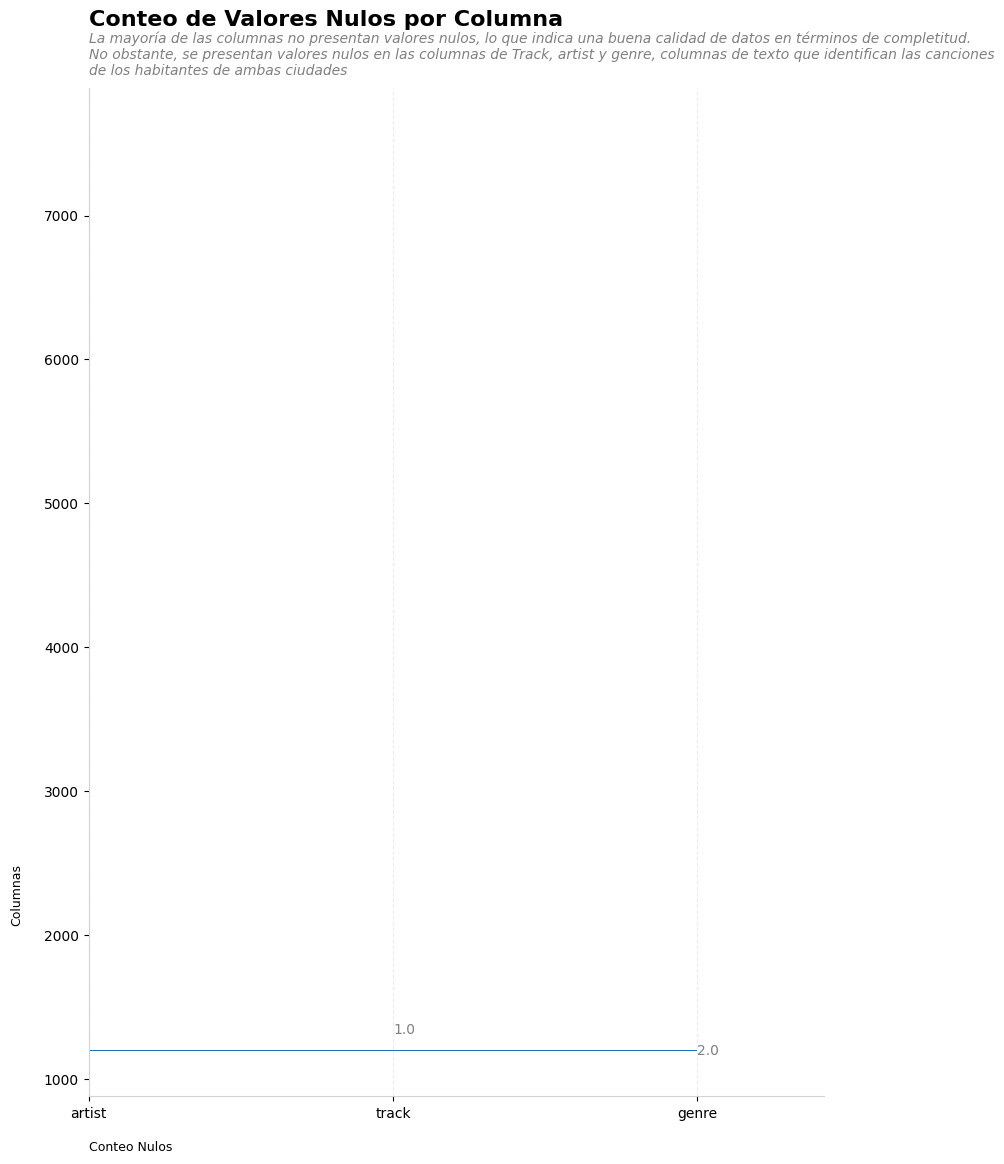

In [35]:
#? 1.1 Generaciond de una visualizacion de los resultados de los valores nulos
crear_barchart_storytelling(
    data=null_data,
    x_axis_data=null_data.index,
    x_axis_title='Conteo Nulos',
    y_axis_data='Conteo Nulos',
    y_axis_title='Columnas',
    fig_size=(10, 12),
    color_palette=colors,
    order=['artist','track','genre'],
    hue_order=['artist','track','genre'],
    title='Conteo de Valores Nulos por Columna',
    subtitle='La mayoría de las columnas no presentan valores nulos, lo que indica una buena calidad de datos en términos de completitud.\n'
             'No obstante, se presentan valores nulos en las columnas de Track, artist y genre, columnas de texto que identifican las canciones\n'
             'de los habitantes de ambas ciudades'
)


In [36]:
#? 2. Exploracion adicinoal sobre los tipos de valores nulos y la conjuncion de los problemas del dataset


#? 2.1 Extraemos las columnas del analisis, las columnas de track, artist and genre para usar loc en base de nombres mediante [] en lugar de iloc con indices para extraer los datos para el analisis
cols = data_as_is.columns[1:4]

#? 2.2 Aplicamos una bitmask orientada a marcar aquellos valores notna() o no nulos con un 1 y los valores nulos con 0, como una mascara
#? binaria para las tres columnas
null_bits = data_as_is[cols].notna().astype(int)

#? 2.3 Aplicamos un lambda directo hacia la mascara binaria aplicada a las tres columnas para reducir por fila cada uno de los grupos de columnas, y usando estos valores establecer los conteos de valores nulos y las clases.
data_as_is_copy['Clasificacion_Nulos_Binario'] = (
    #? 2.3.1 Internamente aplicamos una funcion apply a las columnas extraidas de data_as_is en donde usamos la data extraida para crear
    #? la nueva clasificacion
    null_bits.apply(
        #? 2.3.2 El string requiere la concatenacion del grupo de columnas en uno solo para generar el bitmap de valor presente o o.
        #? Luego toma la suma de los valores y los formatea con la longitud de las columnas de analisis para determinar cuantos valores hay o no por grupo. Finalmente determina el nombre de la columna que es nula y los une para generar el listado de columnas nulas
        #? lo que nos permite evaluar la distribucion de nulos por grupo de columnas nulas
        lambda r: f"{''.join(map(str, r))} ({r.sum()}/{len(cols)} presentes) - Nulos: {', '.join(cols[r == 0]) or 'Ninguno'}",
        axis=1
))


In [37]:
data_as_is_copy['Clasificacion_Nulos_Binario'].value_counts()

Clasificacion_Nulos_Binario
111 (3/3 presentes) - Nulos: Ninguno                 57184
101 (2/3 presentes) - Nulos: artist                   6062
000 (0/3 presentes) - Nulos: Track, artist, genre      708
001 (1/3 presentes) - Nulos: Track, artist             635
110 (2/3 presentes) - Nulos: genre                     328
100 (1/3 presentes) - Nulos: artist, genre             162
Name: count, dtype: int64

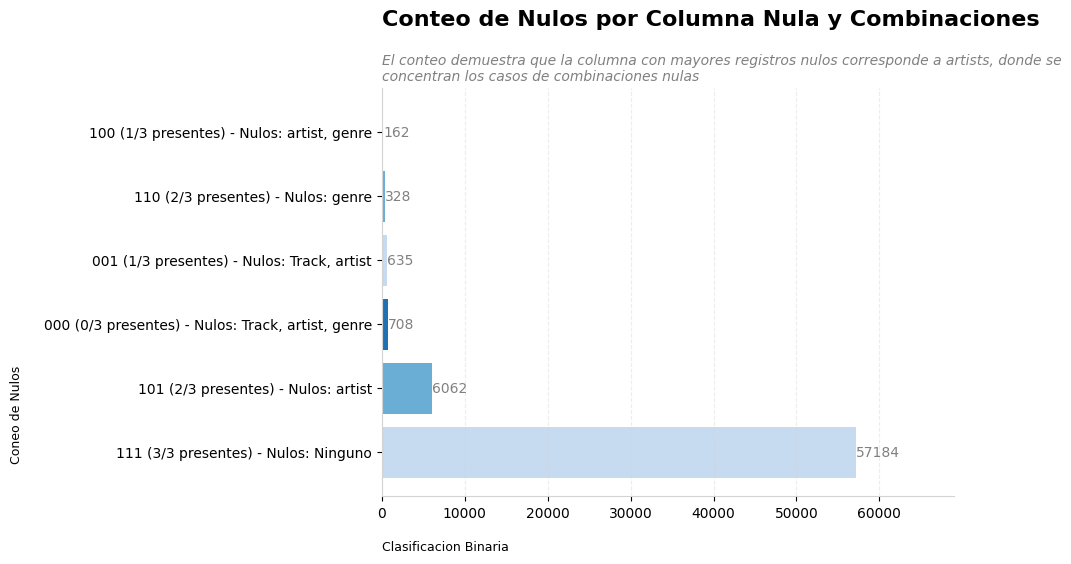

In [38]:
#? 2.1 Visualizacion adicional de la exploracion de los resultados nulos
clasificacion_binaria_extraida = pd.DataFrame(data_as_is_copy['Clasificacion_Nulos_Binario'].value_counts())
crear_barchart_storytelling(
    data=clasificacion_binaria_extraida.reset_index(),
    y_axis_data="Clasificacion_Nulos_Binario",
    x_axis_title='Clasificacion Binaria',
    x_axis_data="count",
    y_axis_title='Coneo de Nulos',
    fig_size=(10,6),
    color_palette=generate_blue_palette(len(clasificacion_binaria_extraida.index)),
    title="Conteo de Nulos por Columna Nula y Combinaciones",
    subtitle="El conteo demuestra que la columna con mayores registros nulos corresponde a artists, donde se\nconcentran los casos de combinaciones nulas")

<hr>

#### Consideración Extra — Contabilización de valores ausentes por columna y determinación de su representación en los datos generales

Para esta subsección, consideramos un flujo de análisis paralelo que ya fue tomado durante la exploración de los datos en la sección anterior, en donde se trabajará para identificar la participación porcentual y numérica de los valores nulos en cada columna con respecto al total de los valores por columna. Luego del análisis de los valores nulos se trabajará con un análisis sobre los valores para determinar la importancia de su eliminación y si se pierde información por cada ciudad.

In [39]:
conteo = data_as_is_copy.groupby("  City  ")["Clasificacion_Nulos_Binario"].value_counts(sort=True)

In [40]:
#? Exploracion inicial base: conteo agrupado por level 0, es decir por ciudad, calcula en base a la contabilizacion total del grupo por ciudad, entonces x.sum()
#? lo que retorna es la cantidad de entradas por ciudad
conteo.groupby(level=0).transform(lambda x: x.sum())

  City       Clasificacion_Nulos_Binario                      
Shelbyville  111 (3/3 presentes) - Nulos: Ninguno                 19719
             101 (2/3 presentes) - Nulos: artist                  19719
             001 (1/3 presentes) - Nulos: Track, artist           19719
             000 (0/3 presentes) - Nulos: Track, artist, genre    19719
             110 (2/3 presentes) - Nulos: genre                   19719
             100 (1/3 presentes) - Nulos: artist, genre           19719
Springfield  111 (3/3 presentes) - Nulos: Ninguno                 45360
             101 (2/3 presentes) - Nulos: artist                  45360
             000 (0/3 presentes) - Nulos: Track, artist, genre    45360
             001 (1/3 presentes) - Nulos: Track, artist           45360
             110 (2/3 presentes) - Nulos: genre                   45360
             100 (1/3 presentes) - Nulos: artist, genre           45360
Name: count, dtype: int64

In [41]:
#? Agrupacion por level 1 hace que se agrupe por la clasificacion, lo que hace que el total de x.sum() sea el total de cada una de las clases sin importar la ciudad
conteo.groupby(level=1).transform(lambda x: x.sum())

  City       Clasificacion_Nulos_Binario                      
Shelbyville  111 (3/3 presentes) - Nulos: Ninguno                 57184
             101 (2/3 presentes) - Nulos: artist                   6062
             001 (1/3 presentes) - Nulos: Track, artist             635
             000 (0/3 presentes) - Nulos: Track, artist, genre      708
             110 (2/3 presentes) - Nulos: genre                     328
             100 (1/3 presentes) - Nulos: artist, genre             162
Springfield  111 (3/3 presentes) - Nulos: Ninguno                 57184
             101 (2/3 presentes) - Nulos: artist                   6062
             000 (0/3 presentes) - Nulos: Track, artist, genre      708
             001 (1/3 presentes) - Nulos: Track, artist             635
             110 (2/3 presentes) - Nulos: genre                     328
             100 (1/3 presentes) - Nulos: artist, genre             162
Name: count, dtype: int64

In [42]:
#? El conteo por nivel [0,1] hace que se pueda contabilizar todos los casos por cada ciudad, dandonos el valor esperado de la salida de la tabla de analisis
conteo.groupby(level=[0,1]).transform(lambda x: x.sum())

  City       Clasificacion_Nulos_Binario                      
Shelbyville  111 (3/3 presentes) - Nulos: Ninguno                 17403
             101 (2/3 presentes) - Nulos: artist                   1770
             001 (1/3 presentes) - Nulos: Track, artist             252
             000 (0/3 presentes) - Nulos: Track, artist, genre      165
             110 (2/3 presentes) - Nulos: genre                      78
             100 (1/3 presentes) - Nulos: artist, genre              51
Springfield  111 (3/3 presentes) - Nulos: Ninguno                 39781
             101 (2/3 presentes) - Nulos: artist                   4292
             000 (0/3 presentes) - Nulos: Track, artist, genre      543
             001 (1/3 presentes) - Nulos: Track, artist             383
             110 (2/3 presentes) - Nulos: genre                     250
             100 (1/3 presentes) - Nulos: artist, genre             111
Name: count, dtype: int64

In [43]:
#? 1. Investigación del aporte general de valores nulos por cada una de las ciudades y las clasificaciones anteriores

#* 1.1 Extrameos la agrupacion por Ciudad y de esta extraemos solo la clasificacion de nulos por las categorias, contando los valores y ordenandolos de manera descendente. Con el group by por ciudad, la data no tiene una agrupacion real hasta que definimos que tome la columna de clasificacion binario y cuente los
# valores de este campo
conteo = data_as_is_copy.groupby("  City  ")["Clasificacion_Nulos_Binario"].value_counts(sort=True)

#* 1.2 Usamos el resultado del conteo para definir un dataframe para visualiaciones, el conteo le da el indice mediante el parametro de index, en donde le digo que tome el indice de conteo, que tiene el indice de dos niveles de ciudad y clasificacion, y registre el valor bajo la columna de conteo
conteo_ciudad_valores_nulos = pd.DataFrame({
    "conteo": conteo,

    #* 1.3 La proporcion se calcula mediante nivel 0, agrupando por ciudad. x en este caso corresponde al valor totalizado de cada value count por ciudad, entonces el primer x seria 17403 de valores no nulos para shelvybille y se le divide para x.sum() es decir la suma de todas las entradas de Shelvybille
    #* para calcular al final la proporcion de cada clase de nulo por ciudad, lo que nos da una idea de la importancia de cada clase de nulo por ciudad
    "proporcion": conteo.groupby(level=0).transform(lambda x: x / x.sum()).apply(lambda v: f"{round(v*100, 2)} %"),

    #* 1.4 Este final header lo que hace es extraer los tres caracteres del codigo por clase usando el indice para la visualizacion
    "small_header" : conteo.index.get_level_values(1).str[:3]
}, index=conteo.index)
conteo_ciudad_valores_nulos


conteo  \
  City      Clasificacion_Nulos_Binario                                 
Shelbyville 111 (3/3 presentes) - Nulos: Ninguno                17403   
            101 (2/3 presentes) - Nulos: artist                  1770   
            001 (1/3 presentes) - Nulos: Track, artist            252   
            000 (0/3 presentes) - Nulos: Track, artist, genre     165   
            110 (2/3 presentes) - Nulos: genre                     78   
            100 (1/3 presentes) - Nulos: artist, genre             51   
Springfield 111 (3/3 presentes) - Nulos: Ninguno                39781   
            101 (2/3 presentes) - Nulos: artist                  4292   
            000 (0/3 presentes) - Nulos: Track, artist, genre     543   
            001 (1/3 presentes) - Nulos: Track, artist            383   
            110 (2/3 presentes) - Nulos: genre                    250   
            100 (1/3 presentes) - Nulos: artist, genre            111   

                                                              proporcion  \
  City      Clasificacion_Nulos_Binario                                    
Shelbyville 111 (3/3 presentes) - Nulos: Ninguno                 88.25 %   
            101 (2/3 presentes) - Nulos: artist                   8.98 %   
            001 (1/3 presentes) - Nulos: Track, artist            1.28 %   
            000 (0/3 presentes) - Nulos: Track, artist, genre     0.84 %   
            110 (2/3 presentes) - Nulos: genre                     0.4 %   
            100 (1/3 presentes) - Nulos: artist, genre            0.26 %   
Springfield 111 (3/3 presentes) - Nulos: Ninguno                  87.7 %   
            101 (2/3 presentes) - Nulos: artist                   9.46 %   
            000 (0/3 presentes) - Nulos: Track, artist, genre      1.2 %   
            001 (1/3 presentes) - Nulos: Track, artist            0.84 %   
            110 (2/3 presentes) - Nulos: genre                    0.55 %   
            100 (1/3 presentes) - Nulos: artist, genre            0.24 %   

                                                              small_header  
  City      Clasificacion_Nulos_Binario                                     
Shelbyville 111 (3/3 presentes) - Nulos: Ninguno                       111  
            101 (2/3 presentes) - Nulos: artist                        101  
            001 (1/3 presentes) - Nulos: Track, artist                 001  
            000 (0/3 presentes) - Nulos: Track, artist, genre          000  
            110 (2/3 presentes) - Nulos: genre                         110  
            100 (1/3 presentes) - Nulos: artist, genre                 100  
Springfield 111 (3/3 presentes) - Nulos: Ninguno                       111  
            101 (2/3 presentes) - Nulos: artist                        101  
            000 (0/3 presentes) - Nulos: Track, artist, genre          000  
            001 (1/3 presentes) - Nulos: Track, artist                 001  
            110 (2/3 presentes) - Nulos: genre                         110  
            100 (1/3 presentes) - Nulos: artist, genre                 100

Este primer análisis determina que para cada una de las ciudades, el 88.25% y el 87.7% de los datos, para Shelbyville y Springfield respectivamente, no tienen valores nulos, marcados por la segmentación `111` que corresponde a aquellos valores donde ni genre ni artist ni track son nulos, es decir más del 75% de cada ciudad y sus datos registrados corresponden a datos completos sin valores nulos. Por otro lado, aquellos valores recuperables, que se han discutido en base de colocar *"Unknown"* en los campos de artists y track para corregir los casos de 101 (conoce track, no conoce artist y conoce genre), o los casos 001 (no se conoce track ni artist, pero se conoce genre), estos dos casos presentan una totalización mayor al 10% de los datos para cada ciudad.

Nótese por ejemplo para Shelbyville, que en análisis posteriores se demostró que tenía menos de la mitad de registros que Springfield, los valores cuya categoría corresponde a `101 y 001` es decir aquellos en donde los nulos son valores que pueden ser rescatados con *"Unknown"* corresponde a una totalización del *11.26%* de todos los registros de datos, correspondientes a *2022* entradas, mientras que aquellos valores que no pueden recuperados, es decir todos los casos `000, 110 y 100` corresponden a un *1.5%* de los datos totales. En este caso, es importante notar que para Shelbyville los valores ausentes corregibles corresponden a un 11.26% es decir un 10% más de todos los datos incorregibles de la base, esto nos demuestra que para esta ciudad, la eliminación de estos valores no es un problema que cause una perdida de información masiva, dado que los nulos incorregibles son muy pocos comparados con el total de registros.

En el caso de Springfield, que tiene una totalización de 45k registros, notamos que en este caso existe una proporción mayor de nulos incorregibles, es decir de casos de tipo `000, 110, y 100` correspondientes al *1.93%* de todos los datos, pero que de igual forma no supera el 2% de todos los datos del dataset como valores nulos no recuperables, mientras que los casos de tipo `101, y 001` correspondientes a los casos recuperables con *"Unknown"* corresponden a un *10.31%* de todos los datos, lo que nos demuestra que para esta ciudad también la eliminación de los valores nulos no recuperables no es un problema grave dado que representan una proporción muy baja del total de datos, mientras que la corrección de los valores nulos recuperables con *"Unknown"* es una corrección que nos permite retener un 10% adicional de los datos, lo que es una cantidad significativa de datos para el análisis posterior.



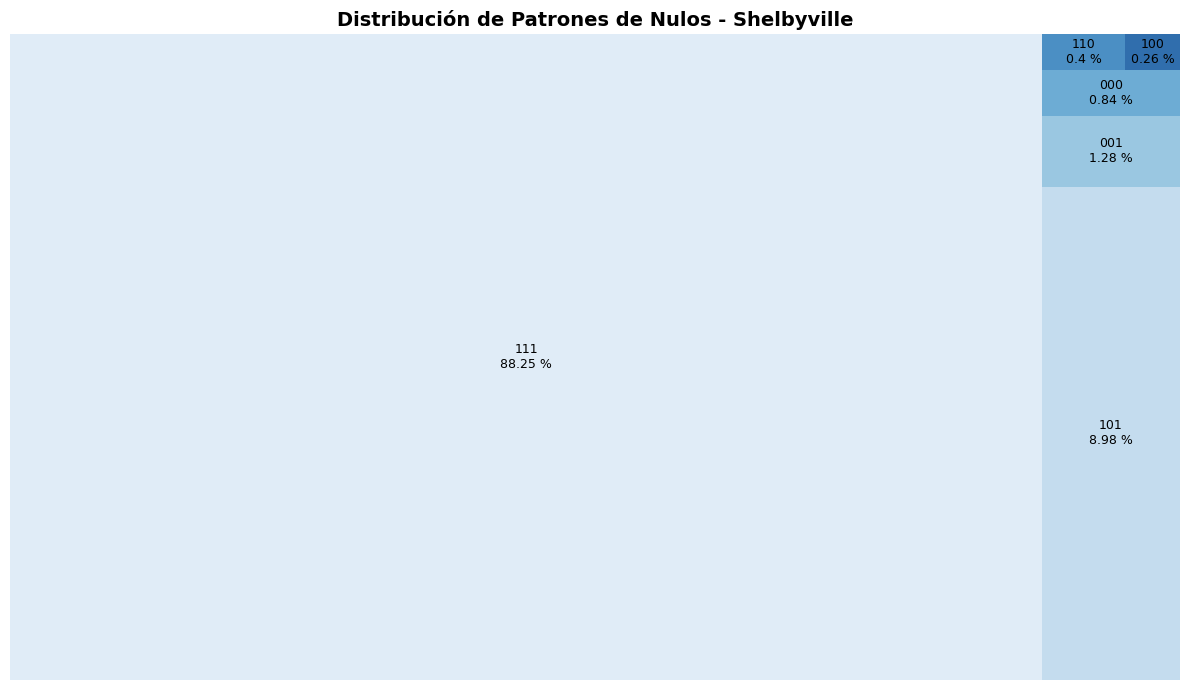

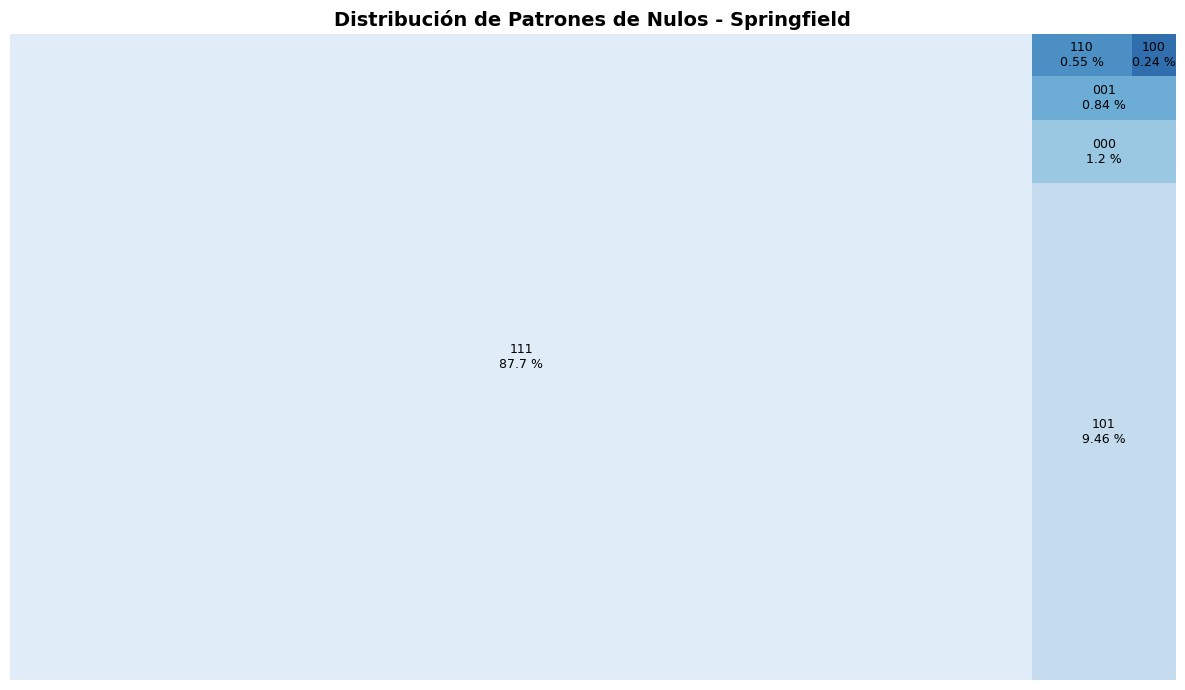

In [44]:
#_ 2. Visualización de la proporción de casos mediante un treemap

for city in conteo_ciudad_valores_nulos.index.get_level_values(0).unique():
    city_data = conteo_ciudad_valores_nulos.loc[city]
    sizes = city_data["conteo"]
    labels = [f"{idx}\n{prop}" for idx, prop in zip(city_data.small_header, city_data["proporcion"])]
    colors = sns.color_palette("Blues", len(sizes))

    fig, ax = plt.subplots(figsize=(12, 7))
    squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.85, ax=ax, text_kwargs={"fontsize": 9})
    ax.set_title(f"Distribución de Patrones de Nulos - {city.strip()}", fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


Como se puede notar ahora visualmente, el peso general de ambas ciudades recae en la data correctamente digitada, con un gran potencial de aumentar esta clasificación en base de la corrección de los grupos en donde falte solamente track o artist.

<hr>
En este caso, la exploración realizada en la anterior sección ya reveló la distribución de los valores nuos por su tipo real, es decir, por la combinación de columnas nulas que determinan si se puede o no corregir estos datos. En este contexto, como se mencionó en la conclusión de la sección anterior, se considera apropiada la eliminación de las entradas 100 (donde aunque se puede corregir artist a "Unknown", genre no puede ser corregido), las entradas 110 donde genre es nulo, y las entradas 000 donde todas las columnas son nulas. En el caso de de los valores duplicados un analisis adicional sobre los datos para identificar aquellos datos donde las combinaciones, similares a las de los valores nulos, nos permitan identificar los grupos correspondientes.

In [45]:
#? 1. Marcado adicional de las entradas por tipo de nulo para una limpieza especial

#? 1.1 Caso 100
data_cleaned['nulo_track_present'] = (data_cleaned['track'].notna() & data_cleaned['artist'].isna() & data_cleaned['genre'].isna()).astype(int)

#? 1.2 Caso 110
data_cleaned['nulo_genre_only'] = (data_cleaned['track'].notna() & data_cleaned['artist'].notna() & data_cleaned['genre'].isna()).astype(int)

#? 1.3 Caso 000
data_cleaned['nulo_all_three'] = (data_cleaned['track'].isna() & data_cleaned['artist'].isna() & data_cleaned['genre'].isna()).astype(int)


In [46]:
data_cleaned[['nulo_track_present','nulo_genre_only','nulo_all_three']]

,nulo_track_present,nulo_genre_only,nulo_all_three
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
65074,0,0,0
65075,0,0,0
65076,0,0,0
65077,0,0,0


In [47]:
#? 2. Eliminamos los tracks registrados en donde la condicion de cualquiera de estas tres columnas se cumpla
data_cleaned = data_cleaned[
    (data_cleaned['nulo_track_present'] == 0) &
    (data_cleaned['nulo_genre_only'] == 0) &
    (data_cleaned['nulo_all_three'] == 0)
].drop(columns=['nulo_track_present', 'nulo_genre_only', 'nulo_all_three'])


Con la limpieza inicial realizada, ahora tenemos menos columnas con errores de registro, en general tenemos *1198* entradas menos, que corresponden a aquellas entradas que caen en las clases 100, 110 y 000. Antes de concretar el relleno de datos, dado que este relleno introduce valores similares, se analizará los casos duplicados por filas. Hay que recalcar que no se considera como duplicados a diferentes registros bajo el mismo userID, a menos que todos los campos registrados sean los mismos en diferentes entradas del dataset.

<hr>

#### Consideración Extra — ¿Qué se hizo en el dataset con los valores ausentes?

En el contexto del dataset propuesto, se consideró oportuno trabajar sin valores nulos en aquellos casos en donde se identificó un valor ausente correspondiente a la columna de *genre* dado que los casos en donde falta este específico valor no pueden derivarse de otros campos con certeza a menos que se identificaran valores similares en las otras columnas. No obstante debido a que no es un requerimiento explícito, dada la cantidad de datos en el dataset, no se considera necesario el relleno de los datos de genre con un valor calculado con mecanismos de búsqueda adicionales sobre los artistas u tracks registrados. Este mismo criterio se aplicó a los registros donde faltaban tanto genre y artista, dado que en base de la canción no se puede identificar directamente el artista y el género, y, por otro lado, también se aplicó esta noción para el caso de los tres valores faltantes.

<hr>

<hr>

#### Consideración Extra — ¿Cuáles podrían ser las razones detrás de los campos faltantes?

Dentro de un sistema digital, el registro de la actividad de los usuarios generalmente es prioritario por la importancia que tiene dentro de modelos predictivos y analíticas sea para la toma de decisiones automatizadas de marketing, recomendación de canciones, o de cualquier forma análisis de datos útiles en el contexto del negocio, por lo que registros de este estilo, tomados de una aplicación no deberían de tener errores tan importantes como falta de data clave como un artista o un género.

En este contexto, considero que las posibles razones para la falta de datos, o los problemas del dataset pueden ser:

1. **Digitación Externa**: si los datos no son de aplicaciones, sino de una encuesta o un sistema tercerizado es posible que la encuesta haya permitido entradas sin validación apropiada que causen errores en la digitación de datos.
2. **Fallos en sistemas automatizados**: si los datos fueron tomados a través de sistemas como APIs, Web Scraping u otras herramientas conectadas a los sistemas base de las plataformas de streaming de música que pueden estar usandose dentro de Springfield o Shelbyville, es posible que existieran fallos como bloqueos de tipo *rate limit*, acceso bloqueado, etc. que no permitieron que para todos los usuarios, todos los datos se guarden apropiadamente, lo que generó un dataset con valores faltantes.
3. **Errores en la exportación o almacenamiento de datos**: es posible que al almacenar los datos luego de su extracción, los datos hayan sufrido corrupciones durante su almacenamiento, y se haya perdido registro por problemas de recuperaciones de datos que no lograron arreglar todo el contenido del archivo, o por archivos corruptos que dañaron el dataset total, generando faltas de datos dado que se intentó hacer arreglos manuales.

En general, la causa más atribuible a la falta de datos en este tipo de dataset es a errores humanos de digitación, pero esto se asume en base de la consigna que los datos hayan sido recopilados manualmente para los ciudadanos de Springfield y Shelbyville. No obstante también se puede considerar errores en sistemas automatizados de recolección dado a errores intermitentes que causaron que datos se recopilen con valores faltantes por problemas de acceso a los datos requeridos.
<hr>

Una vez se ha realizado la limpieza de los valores no corregibles, es momento de realizar una corrección de aquellos valores que están registrados de manera incorrecta. Es decir, hay que pasar a la corrección de los datos que se encuentran en los grupos `101 y 001` corregibles.

In [48]:
#? 1. Para el proceso de corrección el proceso es simple, se trabajará con el relleno de valores nulos con "Unknown"
data_cleaned['track'] = data_cleaned['track'].fillna(value='Unknown')
data_cleaned

,userid,track,artist,genre,city,time,day
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,20:28:33,Wednesday
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,14:07:09,Friday
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,20:58:07,Wednesday
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,08:37:09,Monday
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,08:34:34,Monday
...,...,...,...,...,...,...,...
65074,729CBB09,My Name,McLean,rnb,Springfield,13:32:28,Wednesday
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Shelbyville,10:00:00,Monday
65076,C5E3A0D5,Jalopiina,NaN,industrial,Springfield,20:09:26,Friday
65077,321D0506,Freight Train,Chas McDevitt,rock,Springfield,21:43:59,Friday


In [49]:
data_cleaned.info()

<class 'pandas.DataFrame'>
Index: 63881 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   userid  63881 non-null  str  
 1   track   63881 non-null  str  
 2   artist  57184 non-null  str  
 3   genre   63881 non-null  str  
 4   city    63881 non-null  str  
 5   time    63881 non-null  str  
 6   day     63881 non-null  str  
dtypes: str(7)
memory usage: 3.9 MB


In [50]:
data_cleaned['artist'] = data_cleaned['artist'].fillna(value='Unknown')
data_cleaned.info()

<class 'pandas.DataFrame'>
Index: 63881 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   userid  63881 non-null  str  
 1   track   63881 non-null  str  
 2   artist  63881 non-null  str  
 3   genre   63881 non-null  str  
 4   city    63881 non-null  str  
 5   time    63881 non-null  str  
 6   day     63881 non-null  str  
dtypes: str(7)
memory usage: 3.9 MB


Con los datos corregidos podemos pasar a la limpieza de los tipos de datos y de los valores duplicados

### Reemplazo de tipos de Datos por Columna

En esta sección, se trabajará con el mismo dataset `data_cleaned` para modificar los tipos de datos de las columnas según sea necesario para mantener un orden en los datos y facilitar el análisis posterior. En este caso, se trabajará con la transformación de la columna de `time` a un formato de fecha y hora para facilitar el análisis de series de tiempo, dado que el resto de columnas no requieren un cambio fuerte.

<hr>

#### Consideración Extra — ¿Qué columnas fueron necesarias cambiar el tipo de dato y por qué?

En este caso se consideró como prioridad la modificación de la columna *time* dado que esta se está registrando como *string* en lugar de *datetime* lo que dificulta un análisis de línea de tiempo, si fuese necesario realizar, dentro de los días registrados en el dataset, lo que reduce nuestra capacidad analítica sobre los datos temporales que se han considerado importantes en el dataset. Por otro lado, no se ha considerado la modificación adicional de otras columnas dado que el tipo de dato guardado en todas estas ya está normalizado, o es imposible de normalizar dada la estructura de los datos.

Por citar un ejemplo, el proceso de normalización con respecto de la columna de track, artist o genre, es un proceso imposible dado que el sistema ha registrado tanto valores ASCII imprimibles, como UNICODE no estandarizables dado que representan el *locale* de los usuarios, e.g. canciones con título o artista en Chino dado que la canción proviene de ese *locale*. En este caso, estas columnas no requieren un cambio de tipo de dato ni una normalización dado que es data real que se ha compilado dentro del dataset. Si este dataset fuera a ser usado para un sistema de *ML* por ejemplo, se podría considerar la eliminación de estas columnas dado que este tipo de datos, puede no ser requerido por la mayoría de modelos que no están equipados para trabajar con datos no codificados o numéricos.

En resumen, la columna modificada directamente del dataset corrersponde únicamente a la columna *time* que tiene que tener un tipo de dato guardado de datetime, sin importarnos la fecha que se registre en el campo, dado que no es un dato requerido para el análisis, pero sí que la hora sea la misma que se registró originalmente.

<hr>

#### Consideración Extra — ¿Qué sucedería si no se cambia el tipo de dato?

Si no se cambia el tipo de dato, es posible realizar el análisis sin ningún tipo de problema dado que el dato sigue siendo analizable mediante un *parsing* de los datos para extraer la hora del día y considerar si era la mañana, la tarde, madrugada o noche. En este caso si el tipo de dato se cambia entonces el sistema puede eliminar este paso previo, permitiéndonos el acceso directo a la hora para el análisis correspondiente

<hr>


In [51]:
#? 1. Para la correcion del tipo de dato, trabajaremos usando pandas directamente para cambiar el tipo de dato de la columna
data_cleaned['time'] = (
    #? 1.1 Este mecanismo de to_datetime nos permite ingresar los valores de la columna, que en este caso contienen solamente la hora, para que Pandas anada
    #? la informacion de la fecha pertinente, en este caso considera la fecha del EPOCH iniccial que usualmente se mide desde 1900.
    pd.to_datetime(
        data_cleaned['time'], #* Data que tiene que usar para generar el objeto de datetime
        errors='coerce', #* Le decimos a Pandas que en el caso que haya una fecha que no puede convertir la marque con NaT o Not a Time y no lanze excepciones al sistema
    )
)

/var/folders/3c/vp72r8cx1kx1z2gvmfkybjqc0000gn/T/ipykernel_6012/2891155847.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


In [52]:
data_cleaned

,userid,track,artist,genre,city,time,day
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,2026-03-26 20:28:33,Wednesday
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,2026-03-26 14:07:09,Friday
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,2026-03-26 20:58:07,Wednesday
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,2026-03-26 08:37:09,Monday
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,2026-03-26 08:34:34,Monday
...,...,...,...,...,...,...,...
65074,729CBB09,My Name,McLean,rnb,Springfield,2026-03-26 13:32:28,Wednesday
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Shelbyville,2026-03-26 10:00:00,Monday
65076,C5E3A0D5,Jalopiina,Unknown,industrial,Springfield,2026-03-26 20:09:26,Friday
65077,321D0506,Freight Train,Chas McDevitt,rock,Springfield,2026-03-26 21:43:59,Friday


Con la función ejecutada hemos logrado realizar la modificación necesaria para definir a time como una columna de tiempo en donde podemos realizar una modificación adicional al dataset para incluir una columna que marque el segmento de horario requerido para el análisis posterior, es decir, mañana, tarde, noche o madrugada.

In [53]:
#? 2. Para definir la columna, usaremos la informacion de la hora registrada como base, si esta entre las <= 12 y las <6 es la madrugada, desde las 6 <= hasta las < 12 es la manana, 12 <= hasta las < 18 es la tarde, y 18 <= hasta las 12 es la noche.
data_cleaned['time_range'] = data_cleaned['time'].apply(lambda time: 'Madrugada' if 0 <= time.hour < 6 else'Manana' if 6 <= time.hour < 12 else 'Tarde' if  12 <= time.hour < 18 else 'Noche')

In [54]:
data_cleaned

,userid,track,artist,genre,city,time,day,time_range
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,2026-03-26 20:28:33,Wednesday,Noche
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,2026-03-26 14:07:09,Friday,Tarde
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,2026-03-26 20:58:07,Wednesday,Noche
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,2026-03-26 08:37:09,Monday,Manana
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,2026-03-26 08:34:34,Monday,Manana
...,...,...,...,...,...,...,...,...
65074,729CBB09,My Name,McLean,rnb,Springfield,2026-03-26 13:32:28,Wednesday,Tarde
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Shelbyville,2026-03-26 10:00:00,Monday,Manana
65076,C5E3A0D5,Jalopiina,Unknown,industrial,Springfield,2026-03-26 20:09:26,Friday,Noche
65077,321D0506,Freight Train,Chas McDevitt,rock,Springfield,2026-03-26 21:43:59,Friday,Noche


### Remoción de Valores Duplicados

En esta sección se trabajará con el dataset `data_cleaned` para realizar el análisis de los valores duplicados dentro del dataset y su posterior eliminación en base de criterios definidos internamente.

<hr>

#### Consideración Extra — ¿Qué mecanismo se usó para identificar los duplicados y eliminarlos?

Para la eliminación de duplicados se usó el mismo mecanismo base definido dentro de pandas, conocido como `drop_duplicates`, que permite la eliminación por defecto de todas las filas en donde *todas las columnas tengan el mismo valor*. Esta noción, de la igualdad de valores por todas las columnas es importante porque es la forma en la que se ha definido el concepto de duplicado para este dataset también.

En general, para un usuario es posible ser *de la misma ciudad* estar en el *mismo día*, y escuchar la misma canción del mismo artista y encima estar en el mismo *rango horario*, en este caso, tenemos dos posibilidades, si el usuario escucho esta canción en el mismo momento, es decir *time coincide* entonces es un duplicado y tiene que ser eliminado, pero por ejemplo si varía time entonces podemos tomar el registro como un valor real dentro del dataset. Lo mismo puede suceder con cualquier otra columna, dado que aunque hayamos añadido *"Unknown"* a track y artists, si son registros no duplicados, en donde los valores de las otras columnas no sean los mismos entonces se mantendrán los registros, pero si todo es exactamente igual entonces se elimina el registro directamente.

No se ha considerado una desduplicación de datos desde el lado de `userID` debido a que esta columna puede contener dos o tres veces, o `n` veces el registro de un mismo cliente en una misma ciudad, pero con otros diferentes datos, por lo que si bien hay duplicados en la columna de userID, no se la considera como columna de desduplicación dada la necesidad de mantener datos que pueden ser diferentes registros si la primera regla definida en este análisis se cumple, aunque sea un campo varía entre registros

<hr>

In [55]:
#? 1. Exploracion de los duplicados comparados con los valores reales totales
pd.DataFrame(data={
    "Conteo Total Entradas Dataset": pd.Series([data_cleaned.shape[0], 100], index=['data', 'percentage']),
    "Conteo Entradas Duplicadas Dataset":  pd.Series([data_cleaned.duplicated().sum(),(data_cleaned.duplicated().sum()/data_cleaned.shape[0]) * 100] , index=['data','percentage']),
    "Conteo Entradas No Duplicadas Dataset":  pd.Series([data_cleaned.shape[0] - data_cleaned.duplicated().sum(),(data_cleaned.shape[0] - data_cleaned.duplicated().sum())/ data_cleaned.shape[0] * 100], index=['data','percentage'])
}, index=['data','percentage']).transpose()

,data,percentage
Conteo Total Entradas Dataset,63881.0,100.000000
Conteo Entradas Duplicadas Dataset,3755.0,5.878117
Conteo Entradas No Duplicadas Dataset,60126.0,94.121883


A través del análisis anterior, podemos notar que los duplicados en nuestro dataset compenden el *5.87%* de todos los datos registrados, o lo que se traduce a *3755* entradas, comparados con un *94.12%* de datos no duplicados. Teniendo en cuenta estos detalles, es claro que la eliminación de los datos duplicados no afectarían de manera significativa el conteo de entradas para el análisis requerido en la siguiente sección, por lo que se procede a la eliminación de los duplicados en base del criterio anterior, todas las columnas teniendo el mismo valor.

In [56]:
data_cleaned = data_cleaned.drop_duplicates()

In [57]:
data_cleaned

,userid,track,artist,genre,city,time,day,time_range
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Shelbyville,2026-03-26 20:28:33,Wednesday,Noche
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Springfield,2026-03-26 14:07:09,Friday,Tarde
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Shelbyville,2026-03-26 20:58:07,Wednesday,Noche
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Shelbyville,2026-03-26 08:37:09,Monday,Manana
4,E2DC1FAE,Soul People,Space Echo,dance,Springfield,2026-03-26 08:34:34,Monday,Manana
...,...,...,...,...,...,...,...,...
65074,729CBB09,My Name,McLean,rnb,Springfield,2026-03-26 13:32:28,Wednesday,Tarde
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Shelbyville,2026-03-26 10:00:00,Monday,Manana
65076,C5E3A0D5,Jalopiina,Unknown,industrial,Springfield,2026-03-26 20:09:26,Friday,Noche
65077,321D0506,Freight Train,Chas McDevitt,rock,Springfield,2026-03-26 21:43:59,Friday,Noche


### Conclusiones sobre el Preprocesamiento de Datos


En esta sección se aplicaron varios conceptos de exploración de datos, análisis de errores, y mecanismos claros para la eliminación de valores no recuperables y la corrección de aquellos grupos de entradas recuperables. Para esto, se trabajó con un análisis de valores nulos en las tres columnas con la mayor cantidad de valores nulos `track, artist, y genre` que presentaban combinaciones entre sí de entradas con uno, dos o tres valores nulos. En base de las categorías generadas, se procedió a la corrección o eliminación de registros específicos dentro del dataset, reduciendo la cantidad de errores en el dataset de manera mínima, pero que nos permita mantener entradas de datos con todos sus atributos correctamente ingresados.

Por otro lado, para el manejo de duplicados se trabajó con un proceso de identificación primaria de la posible afectación de la eliminación de duplicados, y se trabajó con un mecanismo específico para la eliminación de los duplicados basados en la igualdad de todas las columnas en una entrada, permitiéndonos una reducción de 3755 entradas de datos duplicados.

En definitiva, la base de datos final ya es trabajable, y puede ser usada para el descubirimiento de patrones y pruebas de hipótesis, dado que se han corregido los errores más importantes del dataset, y se han eliminado aquellos registros que no aportan información útil para el análisis requerido, manteniendo la mayor cantidad de datos posibles para el análisis posterior. Si no se hubiese realizado esta tarea de preprocesamiento, el análisis posterior se habría visto afectado por la presencia de datos nulos y duplicados, lo que podría haber llevado a conclusiones erróneas o a la necesidad de realizar un análisis adicional para corregir estos problemas durante el análisis de datos, lo que habría complicado el proceso y podría haber llevado a resultados menos confiables.

## Pruebas de Hipótesis

En esta sección, se trabajará en el desarrollo de tres hipotesis principales mediante un análisis de datos basados en el dataset limpio bajo `data_cleaned` que fue modificada y preparada para esta sección en la seccón anterior. En específico, se tienen las siguientes tres hipótesis que verificar.

1. La actividad de los usuarios difiere según el día de la semana y dependiendo de la ciudad.
2. Los lunes por la mañana, los habitantes de Springfield y Shelbyville escuchan diferentes géneros. Lo
mismo ocurre con los viernes por la noche.
3. Los oyentes de Springfield y Shelbyville tienen distintas preferencias. En Springfield prefieren el pop
mientras que en Shelbyville hay más aficionados al rap.

Cada una de estas hipótesis serán analizadas a detalle, correspondiendo claramente con la cantidad de datos y el nivel propio de detalle del dataset, para dar una respuesta validad en los datos registrados en el dataset.


### Hipótesis 1: Actividad Difiere según el día de la semana y dependiendo de la ciudad.

En este caso, antes de responder analíticamente la hipotesis, es prudente analizar la noción de `actividad` en el contexto del dataset. Bajo los datos registrados, la noción de actividad se refiere a las canciones registradas bajo el dataset, registradas por usuario, que se  pueden medir en base de agrupaciones por ciudad, día, rango horario, género, etc. Estos datos registrados en el dataset,al representar reproducciones de canciones por parte de n usuarios, representan la actividad de los usuarios a lo largo de los días registrados durante la recolección de datos. En este sentido,para analizar la variación entre la actividad dependiendo del día de la semana y ciudad, se debe tomar en cuenta una *totalización* de los registros de reproducciones de canciones, independiente de los artistas, géneros o títulos.

Para realizar esto entonces, es necesario usar el dataset modificado y limpiado, realizando una agrupación individual general por ciudad, luego por día, y por último una agrupación general con doble nivel de índice, siempre manteniendo los valores como el conteo de track.

In [58]:
#? 1. Exploracion inicial correspondiente a una agrupacion por ciudad  en general y conteo de tracks
exploracion_ciudad = pd.DataFrame(data_cleaned.groupby(by='city')['track'].count().rename('Conteo de Canciones por Ciudad')).rename(columns={'city':'Ciudad'})
cantidad_canciones_totales_dataset = data_cleaned['track'].count()
#? 1.1 Anaidmos totalizacion porcentual con respecto al total de canciones

for entry in exploracion_ciudad.index:
    conteo_ciudad  = exploracion_ciudad.loc[entry, 'Conteo de Canciones por Ciudad']
    porcentaje_ciudad = (conteo_ciudad / cantidad_canciones_totales_dataset) * 100
    exploracion_ciudad.loc[entry,'Porcentaje Con Respecto al Total General'] =  porcentaje_ciudad

exploracion_ciudad.index.name = 'Ciudad'

exploracion_ciudad

,Conteo de Canciones por Ciudad,Porcentaje Con Respecto al Total General
Ciudad,,
Shelbyville,18234,30.326315
Springfield,41892,69.673685


In [59]:
#? 2. Exploracion inicial correspondiente a una agrupacion por dia en general y conteo de tracks
exploracion_dias = pd.DataFrame((data_cleaned.groupby(by='day')['track'].count()).rename('Conteo de Canciones por Dia'))
cantidad_canciones_totales_dataset = data_cleaned['track'].count()
#? 2.1 Anadimos contabilizacion porcentual para exploracion adicional
for entry in exploracion_dias.index:
    conteeo_dia = exploracion_dias.loc[entry, 'Conteo de Canciones por Dia']
    porcentaje_dia = (conteeo_dia / cantidad_canciones_totales_dataset) * 100
    exploracion_dias.loc[entry,'Porcentaje Con Respecto al Total de Entradas'] =  porcentaje_dia
exploracion_dias.index.name = 'Dia de la Semana'
exploracion_dias

,Conteo de Canciones por Dia,Porcentaje Con Respecto al Total de Entradas
Dia de la Semana,,
Friday,21482,35.728304
Monday,20866,34.703789
Wednesday,17778,29.567907


In [60]:
#? 3. Exploracion adicional con doble nivel de indice por ciudad y dia, para analizar la actividad por ciudad y por dia en conteo y porcentaje
exploracion_ciudad_dia = pd.DataFrame(data_cleaned.groupby(by=['city','day'])['track'].count().rename('Conteo de Canciones por Ciudad y Dia')).sort_values(by='Conteo de Canciones por Ciudad y Dia', ascending=False)
totalizacion_escucha_springfield = exploracion_ciudad.loc['Springfield','Conteo de Canciones por Ciudad']
totalizacion_escucha_shelvybille= exploracion_ciudad.loc['Shelbyville','Conteo de Canciones por Ciudad']


#? 3.1 Anaidmos contabilizacion porcentual sobre cada uno de los grupos basandonos en los dos niveles de indices que tenemos
for city, day  in exploracion_ciudad_dia.index:
    conteo_ciudad_y_dia_juntos = exploracion_ciudad_dia.loc[(city, day),'Conteo de Canciones por Ciudad y Dia']
    porcentaje_por_grupo = (conteo_ciudad_y_dia_juntos / (totalizacion_escucha_springfield if city == 'Springfield' else totalizacion_escucha_shelvybille)) * 100
    exploracion_ciudad_dia.loc[(city, day),'Porcentaje Con Respecto al Total de Escucha por Ciudad'] = porcentaje_por_grupo

#?  3.2 Anadimos la diferencia entre las dos ciudades en los mismos dias
for day in exploracion_ciudad_dia.index.get_level_values(1).unique():
    conteo_springfield = exploracion_ciudad_dia.loc[('Springfield', day), 'Porcentaje Con Respecto al Total de Escucha por Ciudad']
    conteo_shelvybille = exploracion_ciudad_dia.loc[('Shelbyville', day), 'Porcentaje Con Respecto al Total de Escucha por Ciudad']
    diferencia = conteo_springfield - conteo_shelvybille
    exploracion_ciudad_dia.loc[('Springfield', day), 'Diferencia Springfield - Shelbyville'] = diferencia
    exploracion_ciudad_dia.loc[('Shelbyville', day), 'Diferencia Springfield - Shelbyville'] = diferencia

exploracion_ciudad_dia

Conteo de Canciones por Ciudad y Dia  \
city        day                                               
Springfield Friday                                    15680   
            Monday                                    15347   
            Wednesday                                 10865   
Shelbyville Wednesday                                  6913   
            Friday                                     5802   
            Monday                                     5519   

                       Porcentaje Con Respecto al Total de Escucha por Ciudad  \
city        day                                                                 
Springfield Friday                                             37.429581        
            Monday                                             36.634680        
            Wednesday                                          25.935740        
Shelbyville Wednesday                                          37.912691        
            Friday                                             31.819678        
            Monday                                             30.267632        

                       Diferencia Springfield - Shelbyville  
city        day                                              
Springfield Friday                                 5.609903  
            Monday                                 6.367048  
            Wednesday                            -11.976951  
Shelbyville Wednesday                            -11.976951  
            Friday                                 5.609903  
            Monday                                 6.367048

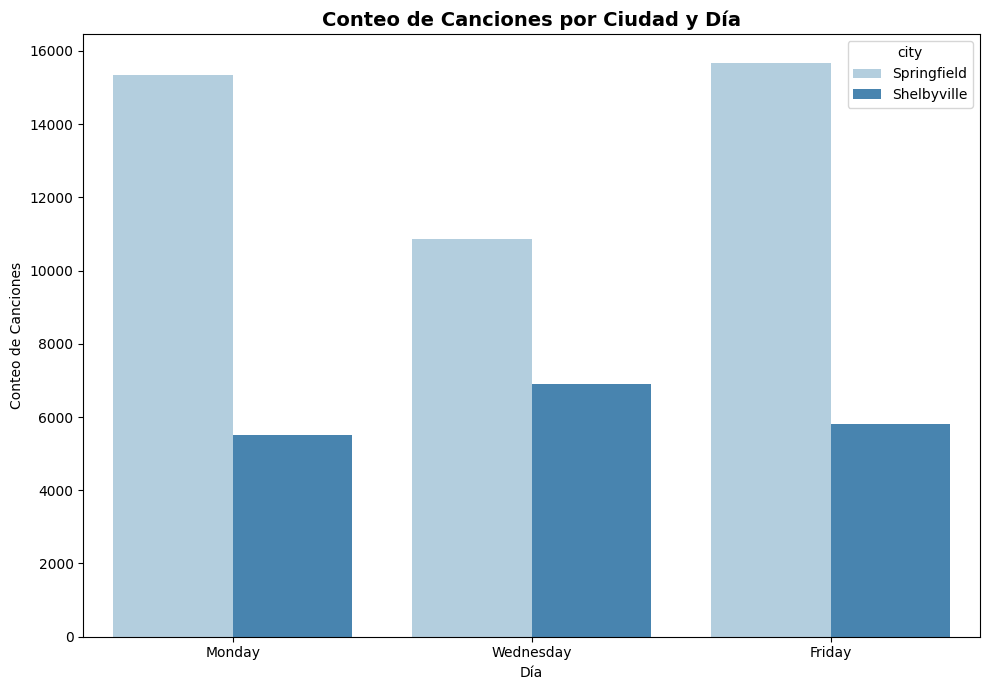

In [61]:
#?4. Visualizacion exploratoria de los datos agrupados
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=exploracion_ciudad_dia.reset_index(),
            x='day', y='Conteo de Canciones por Ciudad y Dia',
            hue='city', palette='Blues', ax=ax,
            order=['Monday', 'Wednesday', 'Friday'])
ax.set_title("Conteo de Canciones por Ciudad y Día", fontsize=14, fontweight='bold')
ax.set_xlabel("Día")
ax.set_ylabel("Conteo de Canciones")
plt.tight_layout()
plt.show()


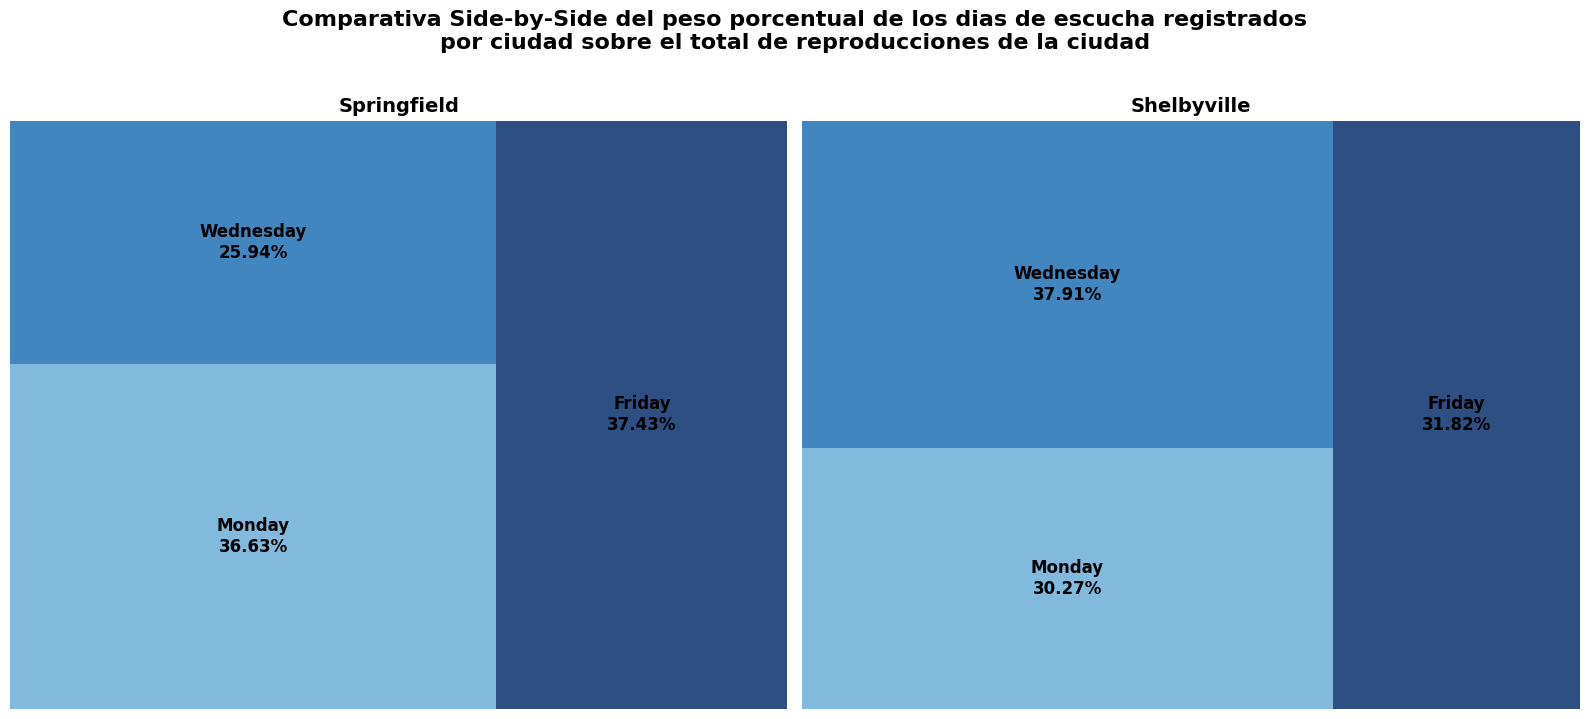

In [62]:
#? C[odigo de visualizacion creado a traves de Amazon Q con el modelo Automatico, creeria que es Claude Sonnet 4, para la visualizacion de los porcentajes

days_order = ['Monday', 'Wednesday', 'Friday']
cities = exploracion_ciudad_dia.index.get_level_values(0).unique()
colors_by_day = {'Monday': '#6baed6', 'Wednesday': '#2171b5', 'Friday': '#08306b'}

#* Treemaps comparativos por ciudad
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, city in zip(axes, cities):
    city_data = exploracion_ciudad_dia.loc[city].reindex(days_order)
    pcts = city_data['Porcentaje Con Respecto al Total de Escucha por Ciudad']
    labels = [f"{day}\n{pct:.2f}%" for day, pct in zip(days_order, pcts)]
    colors = [colors_by_day[d] for d in days_order]
    squarify.plot(sizes=pcts, label=labels, color=colors, alpha=0.85, ax=ax,
                  text_kwargs={"fontsize": 12, "fontweight": "bold"})
    ax.set_title(f"{city.strip()}", fontsize=14, fontweight='bold')
    ax.axis('off')
fig.suptitle("Comparativa Side-by-Side del peso porcentual de los dias de escucha registrados\npor ciudad sobre el total de reproducciones de la ciudad", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



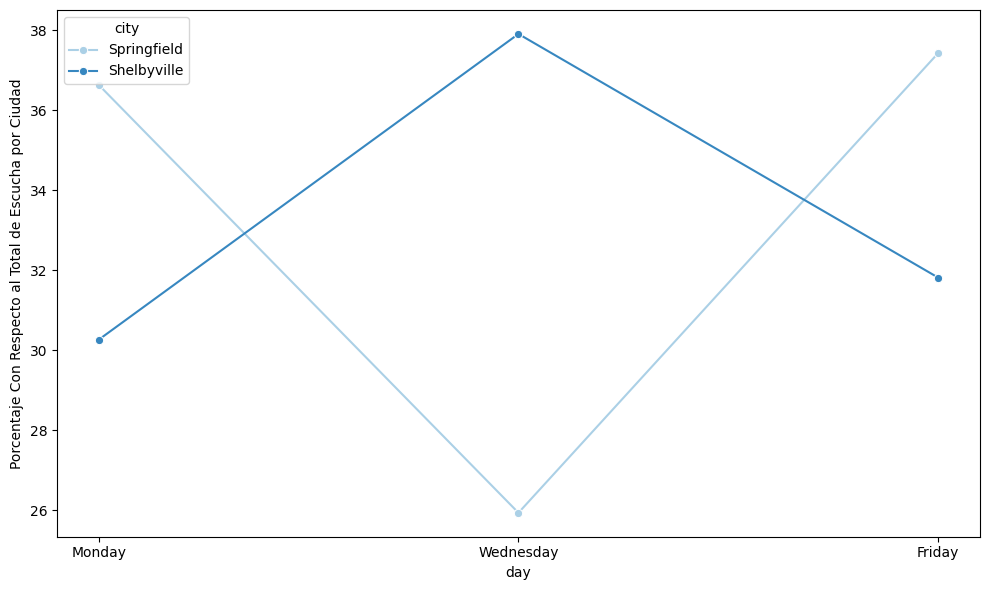

In [63]:
#? Codigo de visualizacion generad por Amazon Q bajo Claude Sonnet 4 para la visualizacion de lineas de la tendencia porcentual de cada dia por ciudad

exploracion_ciudad_dia_reset = exploracion_ciudad_dia.reset_index()
exploracion_ciudad_dia_reset['day'] = pd.Categorical(exploracion_ciudad_dia_reset['day'], categories=['Monday', 'Wednesday', 'Friday'], ordered=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=exploracion_ciudad_dia_reset,
             x='day', y='Porcentaje Con Respecto al Total de Escucha por Ciudad',
             hue='city', marker='o', palette='Blues',
             hue_order=['Springfield', 'Shelbyville'])
plt.tight_layout()
plt.show()


#### Conclusiones

Antes de emitir un juicio sobre la veracidad de la hipótesis planteada, es fundamental considerar un sesgo estructural presente en los datos,

1. Springfield cuenta con aproximadamente 2.29 veces más registros que Shelbyville. Esta desproporción implica que cualquier comparación directa basada en magnitudes absolutas de reproducción favorecerá inherentemente a Springfield, no porque su actividad sea proporcionalmente mayor, sino porque su volumen de datos es superior. En otras palabras, afirmar que Springfield tiene mayor actividad musical un lunes simplemente porque registra 15,347 reproducciones frente a las 5,519 de Shelbyville sería una conclusión incorrecta, derivada del desbalance en la cantidad de registros y no de un patrón real de comportamiento diferenciado.

Para neutralizar este sesgo y obtener una comparación analíticamente válida, se optó por evaluar la participación porcentual de cada día con respecto al total de reproducciones registradas en cada ciudad. Este enfoque transforma las magnitudes absolutas en proporciones relativas, permitiendo comparar la estructura de la actividad musical entre ambas ciudades independientemente del volumen total de datos. Es decir, en lugar de preguntar cuantas canciones se reproducieron y el total por día,pasamos a preguntar y evaluar la hipótesis bajo la distribución porcentual de los datos dentro de sus ciudades y distribuciones por día.

Al analizar los porcentajes resultantes, se revela un hallazgo clave

> La distribución porcentual de actividad entre días es notablemente similar para ambas ciudades. Tanto Springfield como Shelbyville concentran sus picos de actividad en el viernes y el miércoles, con porcentajes de 37.43% y 37.91% respectivamente, y mantienen una participación robusta los lunes, con 36.63% para Springfield y 30.27% para Shelbyville. Esta similitud en la estructura porcentual sugiere que, en términos generales, el patrón de consumo musical semanal no difiere drásticamente entre ambas ciudades. Por lo tanto, los habitantes de ambas localidades tienden a escuchar más música hacia el inicio de la semana, con una diferencia real en el patrón de escucha en la mitad de la semana para ambas ciudades.

Ahondando en el miércoles, Springfield experimenta una caída significativa en su actividad, registrando apenas un 25.94% de sus reproducciones totales en este día, lo que representa una disminución de aproximadamente 11 puntos porcentuales con respecto a miercoles en Shelvybille con 37.91%. En contraste, Shelbyville presenta su mayor porcentaje de actividad en este día, superando incluso su actividad del viernes. Esta divergencia constituye el único punto de diferenciación sustancial entre ambas ciudades. En este caso, mientras Springfield muestra un valle de actividad a mitad de semana, Shelbyville alcanza su pico máximo en ese mismo día.

En síntesis, la hipótesis de que la actividad musical difiere según el día de la semana entre ambas ciudades se comprueba parcialmente. Las magnitudes absolutas no son un indicador confiable debido al desbalance muestral, pero el análisis porcentual revela que, si bien la estructura general de consumo es similar entre ambas ciudades con actividad elevada los lunes y viernes, existe una inversión notable en el comportamiento del miércoles, un día de baja actividad para Springfield y de máxima actividad para Shelbyville. Esta divergencia puntual, enmarcada en un patrón general compartido, sugiere que las diferencias en hábitos de escucha entre ciudades no son generalizadas sino específicas a ciertos días de la semana.


### Hipótesis 2: Generos por Lunes en la Mañana y Viernes por la Noche

Para esta siguiente sección se ha considerado la hipótesis planteada sobre la contabilización de generos y registros por cada ciudad en base a dos horarios específicos, lunes por la mañana y viernes por la noche. Estos dos horarios son los que se usarán para comparar la contabilización de géneros, con lo que se determinará el top 15 de los géneros más populares para ambas ciudades. Para realizar esta implementación, se considerará la creación de una función específica que permita analizar sea por clasificación de rango horario, o por marcador de hora exacta, en donde se compare las entradas en base a dos marcas de tiempo específicas registradas por el usuario.

In [64]:
#? 1. Exploracion inicial de la agregacion de los datos en baes a ciudad, dia y rango horario con contablizacion de track

agrupacion_hip_dos = data_cleaned.groupby(by=["city", "day", "time_range"])["genre"].value_counts(dropna=False).groupby(level=[0,1,2]).nlargest(15).droplevel([0,1,2]).to_frame(name="Conteo de Tracks registrados en el Rango Horario").astype(dtype=np.int32).apply(lambda x: x.astype(bool))
agrupacion_hip_dos

Conteo de Tracks registrados en el Rango Horario
city        day       time_range genre                                                       
Shelbyville Friday    Manana     pop                                                     True
                                 dance                                                   True
                                 electronic                                              True
                                 rock                                                    True
                                 hip                                                     True
...                                                                                       ...
Springfield Wednesday Tarde      metal                                                   True
                                 rusrap                                                  True
                                 soundtrack                                              True
                                 folk                                                    True
                                 latin                                                   True

[270 rows x 1 columns]

In [65]:
#? Extraccion de los datos para lunes por la manana en Springfield y

extracted_monday_morning: pd.DataFrame = agrupacion_hip_dos.loc[('Springfield', 'Monday', 'Manana')]['Conteo de Tracks registrados en el Rango Horario'].rename('Generos de Springfield, Monday Morning').to_frame()
merged_comparative_chart = pd.concat([extracted_monday_morning, agrupacion_hip_dos.loc[('Shelbyville', 'Monday','Manana')]['Conteo de Tracks registrados en el Rango Horario'].rename('Generos de Shelvybilly, Monday Morning').to_frame()], axis=1)

merged_comparative_chart['Generos de Springfield, Monday Morning'] =  merged_comparative_chart['Generos de Springfield, Monday Morning'].fillna(value=False)
merged_comparative_chart['Generos de Shelvybilly, Monday Morning'] = merged_comparative_chart['Generos de Shelvybilly, Monday Morning'].fillna(value=False)
merged_comparative_chart['Esta en Ambos Sets'] = (merged_comparative_chart['Generos de Springfield, Monday Morning'] & merged_comparative_chart['Generos de Shelvybilly, Monday Morning'])


#? Codigo adicional para modificacion visual de la tabla generada para resaltar aquellas entradas False en donde el genero marcado a la izquierda no se encuentra en los generos de ese dia, mientras que marcamos como True aquellos en donde el genero si esta en el listado de generos para ese dia.
def highlight_overlap(row: pd.Series):
    """
    Funcion para retornar una combinacino de formatos estilo CSS para las celdas de una fila. En este caso, la funcion recibe una fila como una serie, donde cada serie que entra tiene como titulo el genero, y le siguen los dos valores, True or False dependiendo de que valor esta en las columnas.
    :param row: Serie correspondiente a un genero
    :return: Por cada serie, una combinacion de colores especifica para el caso de que uno este, y el otro no, etc.
    """

    #? 1. Extraemos los valores de las columnas, en nuestro caso col1 y col2.
    col1, col2, col3 = row.iloc[0], row.iloc[1], row.iloc[2]

    #? 1.1 Revisamos si estan los dos valores, si los dos son True entonces tenemos que retornar un caso base con un color mas oscuro.
    all_present = col1 is not False and col2 is not False and col3 is  not False

    #? 1.2 Si no estan las dos entonces retornamos por cada entrada de la fila una combinacion, clara si es True y oscura si es False para resaltar los casos de falso
    return [
        'background-color: #deebf7; color: black' if v is not False else 'background-color: #08306b; color: white'
        for v in row
    ] if not all_present else ['background-color: #deebf7; color: black'] * 3

#? Aplicamos el estilo a la tabla
merged_comparative_chart


,"Generos de Springfield, Monday Morning","Generos de Shelvybilly, Monday Morning",Esta en Ambos Sets
genre,,,
pop,True,True,True
dance,True,True,True
electronic,True,True,True
rock,True,True,True
hip,True,True,True
ruspop,True,True,True
world,True,True,True
rusrap,True,True,True
alternative,True,True,True


In [66]:
#? Exploracion de viernes por la noche

extracted_friday_night: pd.DataFrame = agrupacion_hip_dos.loc[('Springfield', 'Friday', 'Noche')]['Conteo de Tracks registrados en el Rango Horario'].rename('Generos de Springfield, Friday Night').to_frame()

merged_comparative_chart_two = pd.concat([extracted_friday_night, agrupacion_hip_dos.loc[('Shelbyville', 'Friday','Noche')]['Conteo de Tracks registrados en el Rango Horario'].rename('Generos de Shelvybilly, Friday Night').to_frame()], axis=1)
merged_comparative_chart_two['Generos de Springfield, Friday Night'] =  merged_comparative_chart_two['Generos de Springfield, Friday Night'].fillna(value=False)
merged_comparative_chart_two['Generos de Shelvybilly, Friday Night'] = merged_comparative_chart_two['Generos de Shelvybilly, Friday Night'].fillna(value=False)
merged_comparative_chart_two['Esta en Ambos Sets'] = (merged_comparative_chart_two['Generos de Springfield, Friday Night'] & merged_comparative_chart_two['Generos de Shelvybilly, Friday Night'])


merged_comparative_chart_two.style.apply(highlight_overlap, axis=1)

,"Generos de Springfield, Friday Night","Generos de Shelvybilly, Friday Night",Esta en Ambos Sets
genre,,,
pop,True,True,True
rock,True,True,True
dance,True,True,True
electronic,True,True,True
hip,True,True,True
world,True,True,True
ruspop,True,True,True
classical,True,True,True
alternative,True,True,True


In [67]:
#? 3. Diseno e implementacion de una funcion para filtrado estrategico de datos con parametros establecidos

def extraer_top_generos_de_la_data(data: pd.DataFrame, day_name: str, fecha_inicio_segmentacion: str, fecha_final_segmentacion: str, top_n: int = 15) -> pd.DataFrame:
    """
    Funcion orientada al filtrado estrategico de un dataframe con datos para retornar los valores de los top n generos de ese dia bajo el rango horario establecido.
    :param data: Dataframe con los datos a segmentar
    :param day_name: Dia de la semana a analizar entre Monday, Wednesday y Friday
    :param fecha_inicio_segmentacion: Fecha inicio de la segmentacion en formato hh:mm
    :param fecha_final_segmentacion: Fecha final de la segmentacion en formato hh:mm
    :param top_n: top n generos a obtener (default 15)
    :return: dataframe con los datos
    """
    import re

    #? 1. Validacion del dataframe, aqui validamos si el tiipo de dato de la data es un pd.Dataframe real y si no es nulo, dado que esperamos tener un dataframe de donde extraeer los datos,
    #? lluego validamos si tiene las columnas que necesitamos, i.e. genre, day, time, track y city, para poder realizar los filtros solicitados
    if data is None:
        raise ValueError("El parametro 'data' debe ser un DataFrame de pandas valido, no None ni otro tipo de dato")
    required_cols = {'day', 'genre', 'track', 'city', 'time'}
    missing = required_cols - set(data.columns)
    #? 1.1 Si le falta alguna columna del set de columnas requeridas entonces consideramos que el dataset enviado a la funcion no es correcto y lanzamos un error.
    if missing:
        raise ValueError(f"El DataFrame no contiene las columnas requeridas: {missing}")

    #? 2. Validacion del dia, aqui validamos que sea lunes, miercoles o viernes que son los dias que tiene registrado el dataset, dado que no sabemos de antemano si el dtaset puede
    #? en algun momento tener mas dias, validamos especificamente con el listado de valores unicos de la columna para la validacion
    if day_name is None or not isinstance(day_name, str) or day_name.strip() == '':
        raise ValueError("El parametro 'day_name' no puede ser nulo ni vacio")
    unique_days = data['day'].unique().tolist()
    #? 2.1 Si no esta en los dias registrados, lanzamos un error
    if day_name not in unique_days:
        raise ValueError(f"El parametro 'day_name' debe ser uno de {unique_days}, se recibio: '{day_name}'")

    #? 3. Validacion del formato hh:mm para fecha inicio y final
    time_pattern = re.compile(r'^\d{2}:\d{2}$') #? Esta validacion se da mediante Regex, que nos permiten identificar patrones correctaente en lugar de manera delimitadores
    for label, val in [('fecha_inicio_segmentacion', fecha_inicio_segmentacion), ('fecha_final_segmentacion', fecha_final_segmentacion)]:
        if val is None or not isinstance(val, str) or val.strip() == '':
            raise ValueError(f"El parametro '{label}' no puede ser nulo ni vacio")
        if not time_pattern.match(val):
            raise ValueError(f"El parametro '{label}' debe tener formato hh:mm, se recibio: '{val}'")

    #? 3.1 Validacion de coherencia temporal: fin debe ser estrictamente mayor que inicio
    h_inicio, m_inicio = map(
        int,
        fecha_inicio_segmentacion.split(':')
    ); #? Aqui partimos en base al delimitadr de los minutos,  transformamos los lados resultantes en enteros para su uso analiticamente
    h_final, m_final = map(
        int,
        fecha_final_segmentacion.split(':')
    )
    if h_final < h_inicio or (h_final == h_inicio and m_final <= m_inicio):
        raise ValueError(f"La fecha final ({fecha_final_segmentacion}) debe ser estrictamente mayor que la fecha inicio ({fecha_inicio_segmentacion})")

    #? 3.2 Validacion de coherencia de valores de tiempo
    if not (0 <= h_inicio < 24) or not (0 <= m_inicio < 60):
        raise ValueError(f"El parametro 'fecha_inicio_segmentacion' tiene valores de hora o minuto no validos: '{fecha_inicio_segmentacion}'")
    if not (0 <= h_final < 24) or not (0 <= m_final < 60):
        raise ValueError(f"El parametro 'fecha_final_segmentacion' tiene valores de hora o minuto no validos: '{fecha_final_segmentacion}'")


    #? 4. Validacion de top_n
    if top_n is None or not isinstance(top_n, int) or top_n <= 0:
        raise ValueError("El parametro 'top_n' debe ser un entero positivo mayor a 0")

    #? 5. Filtrado y extraccion de los top n generos
    time_filter = (
        (data['day'] == day_name) &
        (data['time'].dt.hour * 60 + data['time'].dt.minute >= h_inicio * 60 + m_inicio) &
        (data['time'].dt.hour * 60 + data['time'].dt.minute < h_final * 60 + m_final)
    )

    filtered_springfield = (
        data[time_filter & (data['city'] == 'Springfield')]
            ['genre']
                .value_counts(dropna=False)
                .head(top_n)
                .rename('Generos de Springfield')
                .to_frame()
    )

    filtered_shelbyville = (
        data[time_filter & (data['city'] == 'Shelbyville')]
            ['genre']
                .value_counts(dropna=False)
                .head(top_n)
                .rename('Generos de Shelbyville')
        .to_frame()
    )

    merged_comparative_chart_intern = pd.concat([filtered_springfield, filtered_shelbyville], axis=1)
    merged_comparative_chart_intern = merged_comparative_chart_intern.fillna(False)
    merged_comparative_chart_intern['Esta en Ambos Sets'] = merged_comparative_chart_intern.apply(
        lambda r: r.iloc[0] is not False and r.iloc[1] is not False, axis=1)

    return merged_comparative_chart_intern




table = extraer_top_generos_de_la_data(data_cleaned, 'Monday','06:00','12:00')
table

,Generos de Springfield,Generos de Shelbyville,Esta en Ambos Sets
genre,,,
pop,781.0,218.0,True
dance,549.0,182.0,True
electronic,480.0,147.0,True
rock,474.0,162.0,True
hip,281.0,79.0,True
ruspop,186.0,64.0,True
world,181.0,36.0,True
rusrap,175.0,55.0,True
alternative,164.0,58.0,True


In [69]:
table = extraer_top_generos_de_la_data(data_cleaned, 'Friday','18:00','23:59')
table

,Generos de Springfield,Generos de Shelbyville,Esta en Ambos Sets
genre,,,
pop,713.0,256.0,True
rock,517.0,216.0,True
dance,495.0,210.0,True
electronic,482.0,216.0,True
hip,267.0,94.0,True
world,208.0,54.0,True
ruspop,170.0,47.0,True
classical,163.0,60.0,True
alternative,163.0,63.0,True


Aunque en este caso se ha construido la funcion requerida para el manejo de los generos de Springfield y Shelvybille, bajo un dia y un horario especificado mediante parametros a la funcion, para el análisis de esta pregunta y la respuesta a la validez de la hipótesis no se considera apropiado usar esta funció, sino usar el análisis previo realizado en base a los rangos temporales definidos en el dataset.

En este caso la mañana se considera desde las 06:00 AM hasta las 11:59 AM, mientras que la noche se considera desde las 18:00 PM hasta las 23:59 PM, rango que coincide con lo que se esperaría como un horario de mañana y noche para ambas ciudades.

#### Conclusiones

En base del análisis realizado antes de la definición de la función y la consideración de que se solicita la evaluación de dos horarios específicos, es decir la mañana del lunes y la noche del viernes en el dataset para ambas ciudades, el foco del análisis para esta sección, y con el que se ha intentado responder al planteamiento de la hipótesis corresponde a la revisión de la similitud de los géneros escuchados en las franjas horarias definidas entre las diferentes ciudades del análisis.

En este contexto, observando las tablas de datos calculadas para las franjas temporales solicitadas, podemos notar dos diferentes conclusiones.

1. En el caso del **lunes por la mañana**, se observa una similitud significativa entre los géneros más escuchados en ambas ciudades, esto se demuestra por el bajo nivel de géneros únicos a cada ciudad, aproximadamente **dos del total de 15 géneros analizados**. En vista de estos datos, es importante destacar que para cada ciudad, en el caso del lunes, el **87%** de los datos son repetidos, con géneros registrados tanto en Shelbyville como en Springfield, mientras que el **13%** de los datos son únicos  con. Esto sugiere que, a pesar de las diferencias en la cantidad total de reproducciones, los habitantes de Springfield y Shelbyville comparten preferencias musicales similares durante esta franja horaria específica.
   1. Es interesante notar como en el caso de los géneros disimilares entre las dos ciudades, resaltan entradas como **rap y rnb** que no se registran bajo el top 15 de los géneros que escuchan los habitantes de Springfield durante los lunes por la mañana, pero sí por los habitantes de Shelvybille en la misma franja horaria. Por otro lado, para el día viernes por la noche  la situación cambia con **rnb** donde este género es escuchado por Springfield, pero no por Shelvybille, mientras que **rap** sigue siendo un género asilado en el top 15, en esta franja horaria de viernes por la noche, en Shelvybille, y no en Springfield donde sigue sin aparecer en el top 15.
   2. Por otro lado, variaciones como **rusrap** que ase asume como Russian Rap se encuentra en las listas de reproducción de los habitantes de Shelbyville y Springfield el lunes por la mañana y también en la del viernes siendo un común denominador para los ciudadanos de ambas ciudades.
   3. una situación similar a la que se vive con *rnb** se vive con **latin** que el lunes por la mañana se escucha en Springfield y no en Shelvybille, mientras que si se escucha el viernes por la noche en Shelvybille, pero no en Springfield, mostrando otra vez una relación inversa en los periodos analizados en términos de géneros preferidos por los ciudadanos de ambas ciudades.
   4. Por otro parte, es importante notar que existe un grupo considerable de géneros que se comparten entre Springfield y Shelbyville el lunes por la mañana, entre estos se encuentran: **pop, dance, electronic, rock, hip, world, *ruspop*, alternative, classical, metal, jazz, y soundtrack**, que se encuentran en ambos listados del top 15 géneros más escuchados en la franja horaria seleccionada.

2. En el caso del **viernes por la noche** se observa al igual que lunes por la mañana un alto grado de similitud entre los géneros escuchados por Springfield y por Shelvybille, mostrando al igual que con el lunes que en general el día y la franja horaria no determinan que los ciudadanos de ambas ciudades escuchen géneros distintos a pesar de una parte de la totalización del top 15, que representa un porcentaje minoritario comparado con el total de géneros similares. En vista de estos datos, notamos que para el viernes por la noche se tiene las mismas distribuciones de datos, con diferente orden de los géneros que se prefieren, mostrados por el orden en el que se han colocado en el lado izquierdo, pero en general se mantiene la misma idea de los géneros que se escuchan tanto el viernes como el lunes.
    1. Dentro del viernes, tal como se notó el lunes, géneros como **rap, pop, dance, rock y electronic** entre otros se mantienen en los géneros más escuchados por los ciudadanos de ambas ciudades, siendo estos géneros aquellos que se comparten entre ambas ciudades. Por otro lado, es importante notar que la variación real que presentan estos datos es en su posicionamiento, por ejemplo, el viernes por la noche hay muchas más personas en Shelbyville escuchando música pop que el lunes por la mañana, mientras que en Springfield el pop es el género más escuchado tanto el lunes por la mañana como el viernes por la noche, aunque con una cantidad de reproducciones considerablemente mayor el viernes por la noche, pero con una *cantidad de registros mayor* el lunes por la mañana. Por otro lado, géneros como **latin, rnb y rap** se mantienen como géneros disimilares entre ambas ciudades, siendo estos géneros los que no se comparten entre ambas ciudades, aunque con una situación inversa entre ambos días, con rap y rnb siendo géneros escuchados en Shelbyville, pero no en Springfield el lunes por la mañana, mientras que el viernes por la noche rap y rnb son géneros escuchados en Springfield pero no en Shelbyville.
    2. Es interesante notar que internamente entre lunes y viernes no varían los géneros, pero si varía la actividad de estos géneros, ejemplos como el pop demuestran como evoluciona en diferentes ciudades un género desde el inicio hasta el fin de la semana. Ejemplos adicionales como el salto entre rock de ser una de las primeras categorías el lunes por la mañana para Springfield, a ser la segunda categoría demuestran que la variabilidad entre los géneros no está en cuáles si están en el listado o no, pero en la cantidad de reproducciones que tienen cada uno de estos géneros, lo que se traduce a una variabilidad en la preferencia por estos géneros dependiendo del día y la ciudad, aunque con un listado de géneros similares entre ambas ciudades.

En síntesis, el dataset demuestra que no existe una variación amplia entre los géneros que se registran el lunes por la mañana, comparados con los que se registran el viernes por la noche, en sí la variación de géneros solo corresponde a un aproximado del 13% del top 15 de los géneros registrados, con casos específicos como **latin o rnb** que son preferidos por diferentes ciudades en los diferentes días, mientras que en la otra no se tiene un solo registro alguno de reproducciones de ese género. Por otro lado, se nota claramente que existe una variabilidad en la actividad por reproducción dentro de cada género, no en la variabilidad de las categorías en general. Por ejemplo, existe una variación en Springfield **rock* donde su posición en la clasificación de valores cambia, pero no su presencia dentro del top 15, lo que demuestra que el género sigue siendo uno de los más escuchados, pero con una variabilidad en la cantidad de reproducciones que tiene dependiendo del día, lo que se traduce a una variabilidad en la preferencia por este género dependiendo del día y la ciudad, aunque con un listado de géneros similares entre ambas ciudades independiente del día de la semana, en general para la mayoría de los géneros en el top 15.

Por tanto, la hipótesis de que los lunes por la mañana, los habitantes de Springfield y Shelbyville escuchan diferentes géneros, y lo mismo ocurre con los viernes por la noche, se comprueba parcialmente. Aunque existe una alta similitud en los géneros más escuchados entre ambas ciudades para ambos días, con un porcentaje de similitud del 87% en el top 15 de géneros para cada franja horaria, se identifican diferencias específicas en ciertos géneros como rap, rnb y latin, que son preferidos por una ciudad en un día específico, pero no por la otra ciudad en ese mismo día. Estas diferencias puntuales, aunque minoritarias en términos de cantidad de géneros afectados, indican que sí existen preferencias musicales distintas entre Springfield y Shelbyville para ciertos géneros en las franjas horarias analizadas, aunque la mayoría de los géneros más populares son compartidos entre ambas ciudades.

### Hipótesis 3: Preferencias de Géneros entre Springfield y Shelbyville

Para esta sección se trabajará a través de la tabla de datos cleaned con base en las pautas de análisis definidas para corroborar la hipótesis planteada

In [ ]:
#? 1. Explroracion de la agrupacion por ciudad y genero para obtener el conteo de reproducciones por genero para cada ciudad
data_shelvy_genre = data_cleaned.groupby(by='city')['genre'].value_counts(sort=True).rename('Conteo de Reproducciones').loc['Shelbyville', :]
data_shelvy_genre

In [ ]:
data_spring_genre = data_cleaned.groupby(by='city')['genre'].value_counts(sort=True).rename('Conteo de Reproducciones').loc['Springfield', :]
data_spring_genre

In [ ]:
#? 3. Definiendo el set difference de indices desde Springfield - Shelbyville para determinar generos unicos en springfield
print(f"Generos unicos en Springfield : {set(data_spring_genre.index).difference(set(data_shelvy_genre.index))}")
print(f"Generos unicos en Shelbyville: {set(data_shelvy_genre.index).difference(set(data_spring_genre.index))}")

#### Conclusiones

En este caso, a simple vista el dataset presenta valores similares para los géneros que se encuentran en el top 15, 20 o 25 de ambas ciudades, mostrando que géneros que se mencionaban en la hipótesis como *pop* se encuentran en ambas ciudades y **en ambas son el género favorito por actividad**, lo mismo podemos notar con otros ejemplos como **dance, electronic, hip, y rock* quienes mantienen la misma posición relativa en el chart de los géneros más escuchados en ambas ciudades.

Esto nos muestra que en general, el **top cinco de los géneros más escuchados es el mismo para ambas ciudades**, luego de estos, la diferencia en los géneros no corresponde a si los géneros estan presentes en el top o no, sino en su posición, lo que indica que en las ciudades algunos géneros son más populares que otros, pero siguen siendo similares en términos de gustos ambas ciudades en lo que corresponde a los géneros más populares.

Por otro lado, es importante notar la segunda parte del análisis realizado que compara el set de los géneros registrados por cada tabla de datos, en donde se ha notado que en el caso de Springfield, si existe una alta cantidad de géneros únicos, como por ejemplo **regional** o **colombian** que se encuentran solo en este dataset y no en el lado de Shelbyville. Asimismo, para Shelbyville también hay géneros únicos como **jungle o punjabi**. En este contexto, la hipótesis es cierta, dado que existen géneros únicos que determinan que los patrones de escucha y las preferencias de ambas ciudades no sean las mismas completamente, demostrando que si bien existe un *overlap* claro en géneros más famosos, Springfield tiene un catálogo de géneros explorados mucho más amplio que Shelbyville, demostrando que **sí, Springfield y Shelbyville tienen distintas preferenciasl, con Springfield mostrando mayor diversidad de géneros escuchados, mientras que Shelbyville se concentra en un número más reducido de géneros, aunque con una alta similitud en los géneros más populares entre ambas ciudades**.

## Conclusiones Generales

1. Luego de realizar un análisis completo de los datos se han detectado los siguientes hallazgos importantes:
   - El dataset presenta un **sesgo estructural** significativo, dado que Springfield cuenta con aproximadamente 2.29 veces más registros que Shelbyville, lo que invalida cualquier comparación directa basada en magnitudes absolutas y obliga a trabajar con proporciones relativas para obtener conclusiones analíticamente válidas.
   - En términos de **actividad musical por día de la semana**, la distribución porcentual entre ambas ciudades es notablemente similar, con picos de actividad concentrados en lunes y viernes. Sin embargo, se identifica una **inversión significativa en el miércoles**: Springfield registra su punto más bajo de actividad (25.94%) mientras que Shelbyville alcanza su pico máximo (37.91%), constituyendo la única divergencia sustancial en los patrones de escucha semanal entre ambas ciudades.
   - En cuanto a las **preferencias de género por franja horaria**, el análisis del lunes por la mañana y el viernes por la noche revela que el **87% de los géneros del top 15 son compartidos** entre ambas ciudades, independientemente del día y la hora. Las diferencias se limitan a géneros específicos como **rap, rnb y latin**, que presentan una relación inversa entre ciudades y días, donde géneros ausentes en una ciudad durante una franja horaria aparecen en la otra, y viceversa. La variabilidad real no radica en qué géneros se escuchan, sino en la **intensidad de reproducción** de cada género según el día y la ciudad.
   - Al evaluar las **preferencias generales de género**, el top cinco de géneros más escuchados (**pop, dance, electronic, rock y hip**) es idéntico para ambas ciudades y mantiene la misma posición relativa. No obstante, Springfield exhibe un **catálogo de géneros explorados significativamente más amplio**, con géneros únicos como **regional o colombian**, mientras que Shelbyville presenta sus propios géneros exclusivos como **jungle o punjabi**, aunque en menor cantidad. Esto confirma que, si bien existe un alto grado de coincidencia en los géneros populares, Springfield muestra mayor diversidad en sus hábitos de escucha frente a una Shelbyville más concentrada en un número reducido de géneros.
2. Luego de realizar el análisis de los datos de la sección de preprocesamiento y de exploración de los datos, se han detectado los siguientes hallazgos importantes:
   - El dataset original presentaba un **estado sucio considerable**, de las 65,079 entradas, el **12% (7,895 casos)** contenía valores nulos distribuidos en las columnas de *track, artist y genre*, con combinaciones de **una, dos o tres columnas afectadas simultáneamente**. Adicionalmente, los nombres de las columnas presentaban formato incorrecto con espacios fuera de lugar, y la columna *time* se encontraba almacenada como cadena de texto en lugar de un objeto datetime.
   - Las columnas de **City, time y Day** se identificaron como las **columnas pivote del análisis**, al no presentar valores faltantes y mantener un formato estándar consistente, mientras que las columnas de contenido musical (track, artist, genre) requerían intervención directa antes de ser utilizables para el análisis de hipótesis.
   - Se detectó la presencia de **caracteres extendidos UTF** (chino, cirílico, japonés, coreano, entre otros) en las columnas de texto, lo cual es consistente con un dataset de música internacional recolectado sin normalización de *locale*, y que al no requerir la aplicación de modelos de *machine learning* no representa un problema crítico para el análisis actual.
   - Para la corrección de datos se aplicó una **estrategia diferenciada por tipo de nulo**, donde se eliminó **708** entradas con los tres campos vacíos por ser irrecuperables, eliminación de registros sin género por imposibilitar la agregación correcta, y relleno con *"Unknown"* en los campos de artist y track para aquellos registros que conservaban el género, priorizando la retención de datos útiles para un análisis centrado en géneros, días y horas de escucha.
   - En el manejo de duplicados se identificaron y eliminaron **3,755 entradas duplicadas** basándose en la igualdad completa de *todas las columnas*, precedido por un análisis de impacto para asegurar que la eliminación no comprometiera la integridad del dataset.


## Referencias
[1] N. P. Juan Felipe, Introducción a Python: Clase #8, Quito, Pichincha: USFQ, 2026.

[2] LABarnard, "Pandas to_datetime - setting the date when only times (HH:MM) are input," Stack Overflow, 06 03 2015. [Online]. Available: https://stackoverflow.com/questions/28901444/pandas-to-datetime-setting-the-date-when-only-times-hhmm-are-input. [Accessed 25 03 2026].

[3] NumFOCUS, "pandas.Series.rename," NumFOCUS Pandas, [Online]. Available: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.rename.html. [Accessed 25 03 2026].

[4] Amazon Q Developer, "Comparison Charts using Squarify for Treemap Comparison," Amazon Web Services, generated Mar 26, 2026. [Online]. Available: https://aws.amazon.com/q/developer/

[5] Amazon Q Developer, "Line Graph Design and Order Definition," Amazon Web Services, generated Mar 26, 2026. [Online]. Available: https://aws.amazon.com/q/developer/

[6] Amazon Q Developer, "Expand Bar Chart Storytelling Function with More Attributes," Amazon Web Services, generated Mar 26, 2026. [Online]. Available: https://aws.amazon.com/q/developer/

[7] Amazon Q Developer, "Funcion Standarization for Genre Based Time Splitting," Amazon Web Services, generated Mar 26, 2026. [Online]. Available: https://aws.amazon.com/q/developer/

